# Retail Customer Segmentation & Sales Analysis

**IBM SkillsBuild Data Analytics with AI — Academic Internship Programme**
BharatCares in association with AICTE

| | |
|---|---|
| **Author** | Aryan Verma |
| **Dataset** | [UCI Machine Learning Repository — Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) |
| **Scope** | 1,067,371 invoice lines · 01 Dec 2009 – 09 Dec 2011 · 43 countries |
| **Stack** | Python · pandas · NumPy · Matplotlib · scikit-learn |

---

## 1. Business problem

A UK-based online giftware retailer has two years of transaction history but no
view of *who* its customers are. Marketing spend is undifferentiated: the same
campaign goes to a customer who ordered yesterday and to one who has not ordered
in 18 months. Management wants three questions answered from the data it already
owns:

1. **Where does revenue actually come from** — which products, countries and
   months, and how concentrated is it?
2. **Which customers matter** — can the base be split into a small number of
   groups that deserve genuinely different treatment?
3. **What is a customer worth**, and how much of the base is quietly churning?

## 2. Analytical approach

| Stage | What is done | Why |
|---|---|---|
| Data quality audit | Quantify missing values, duplicates, cancellations, negative quantities, non-product codes | Decide the cleaning rules from evidence, not habit |
| Cleaning | Nine documented steps, each logged with its row and revenue impact | An auditable trail — every number below is traceable to a rule |
| Descriptive analysis | Revenue trend, demand rhythm, products, geography, returns | Establish the baseline the segmentation has to explain |
| Concentration | Pareto curve of revenue by customer | Test whether segmentation is even worth doing |
| RFM segmentation | Recency / Frequency / Monetary quintile scoring → named segments | Transparent, rule-based, directly actionable |
| K-Means clustering | Unsupervised clustering on log-scaled RFM (scikit-learn) | Let the data propose its own groups, then compare against the rules |
| Customer Lifetime Value | Historical value + a rate-based 12-month projection | Turn segments into a budget |
| Cohort retention | Monthly acquisition cohorts × months since first order | Separate a growth problem from a retention problem |

## 3. How to run this notebook

```bash
pip install -r requirements.txt
jupyter notebook AryanVerma_RetailCustomerSegmentationAnalysis.ipynb
```

Run the cells in order. The first data cell downloads the 45 MB source workbook
from the UCI repository if it is not already present and caches a combined CSV,
so the download happens **once**. No API keys, credentials or manual downloads
are needed. Nothing outside this repository folder is written to.

---
# 4. Environment and imports

Versions are printed rather than assumed, so that any result in this notebook can
be tied to the exact library versions that produced it.

In [1]:
# --- Standard library -------------------------------------------------------
import json
import platform
import re
import sys
import urllib.request
import zipfile
from importlib.metadata import version
from pathlib import Path

# --- Third party ------------------------------------------------------------
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("python      ", sys.version.split()[0])
print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("matplotlib  ", mpl.__version__)
print("scikit-learn", sklearn.__version__)

python       3.14.6
pandas       3.0.5
numpy        2.5.3
matplotlib   3.11.2
scikit-learn 1.9.1


In [2]:
# Paths are all relative to the repository root, which is where this notebook lives.
ROOT = Path.cwd()
DATA = ROOT / "data"
RAW = DATA / "raw"
OUTPUTS = ROOT / "outputs"
FIGS = OUTPUTS / "figures"
for d in (RAW, FIGS):
    d.mkdir(parents=True, exist_ok=True)

SOURCE_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
ZIP_PATH = RAW / "online_retail_II.zip"
XLSX_PATH = RAW / "online_retail_II.xlsx"
CACHE_PATH = DATA / "online_retail_II.csv"  # combined sheets, written once

# FACTS collects every headline number this notebook computes. It is written to
# outputs/facts.json at the end so the written report quotes computed values
# instead of hand-copied ones.
FACTS = {}
FIGURES = {}

def fact(key, value):
    """Record a headline number and return it unchanged."""
    FACTS[key] = value
    return value


# The report quotes the software stack, so measure it here rather than typing it
# into the document: whatever interpreter ran this notebook is what gets printed.
fact("env_python", platform.python_version())
fact("env_pandas", pd.__version__)
fact("env_numpy", np.__version__)
fact("env_matplotlib", mpl.__version__)
fact("env_sklearn", sklearn.__version__)
fact("env_openpyxl", version("openpyxl"))
fact("env_notebook", version("notebook"))

# Only the folder name: the absolute path is specific to whoever ran the notebook and
# has no business being stored in a cell output that gets committed and submitted.
print("repository root:", ROOT.name)

repository root: retail-customer-segmentation


## 4.1 Chart theme

Every chart in this notebook is drawn through one theme so that colour carries
meaning consistently:

* **Categorical palette** — four hues assigned in a fixed order and never
  cycled. The palette was checked for colour-vision-deficiency separation
  (worst adjacent pair ΔE 9.1 under protanopia, against a floor of 8) so the
  series stay distinguishable for red–green colourblind readers.
* **Sequential ramp** — a single hue, light to dark, used for magnitude
  heatmaps. Never a rainbow, because a rainbow implies an order that hue does
  not have.
* Grid lines are hairline and recessive; there are no dual-axis charts, and no
  pie charts. Every chart is accompanied by the table it was drawn from, so no
  value is readable only by eye.

In [3]:
SURFACE = "#fcfcfb"    # chart surface
INK = "#0b0b0b"        # primary text
INK_2 = "#4a4a48"      # secondary text (values, labels)
INK_MUTED = "#77776f"  # tick labels, notes
GRID = "#e6e6e2"       # hairline grid

# Categorical palette - fixed order, never cycled. Colour follows the entity,
# never its rank, so a filtered chart does not repaint the survivors.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
BLUE, ORANGE, GREEN, AMBER = PALETTE

# Sequential ramp: one hue, light -> dark.
SEQ = LinearSegmentedColormap.from_list(
    "seq_blue", ["#f4f7fc", "#cfdff4", "#8fb6e8", "#3f86da", "#164a86"]
)

mpl.rcParams.update({
    "figure.figsize": (10, 5.2), "figure.dpi": 100, "savefig.dpi": 150,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10.5, "text.color": INK,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.labelsize": 10, "axes.titlesize": 13.5, "axes.titleweight": "semibold",
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titlepad": 16,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "lines.linewidth": 2, "lines.markersize": 8,
})


def money(v, _pos=None):
    """Currency axis formatter. The dataset is a UK retailer, so values are GBP."""
    sign = "-" if v < 0 else ""
    a = abs(v)
    if a >= 1e6:
        return f"{sign}£{a / 1e6:,.1f}M"
    if a >= 1e3:
        return f"{sign}£{a / 1e3:,.0f}k"
    return f"{sign}£{a:,.0f}"


GBP = FuncFormatter(money)


def titled(ax, title, subtitle=None):
    """Left-aligned title with an optional muted subtitle above the axes."""
    ax.set_title(title)
    if subtitle:
        ax.annotate(subtitle, xy=(0, 1.02), xycoords="axes fraction", ha="left",
                    va="bottom", fontsize=9.5, color=INK_MUTED)


def label_barh(ax, ys, values, texts=None, fmt=money, pad=0.012):
    """Direct-label horizontal bars. Values stay in ink, never the series colour.

    `ys` must be the same positions the bars were drawn at. Several charts here
    draw at np.arange(n)[::-1] to put rank one on top, so labelling by loop
    index instead would mirror every label onto the wrong bar.
    """
    span = max((abs(v) for v in values), default=1) or 1
    for i, (pos, v) in enumerate(zip(ys, values)):
        txt = fmt(v) if texts is None else texts[i]
        ax.annotate(txt, xy=(v + pad * span * (1 if v >= 0 else -1), pos), va="center",
                    ha="left" if v >= 0 else "right", fontsize=9, color=INK_2)


def save(fig, name):
    """Persist a figure for the written report and register it."""
    path = FIGS / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    FIGURES[name] = path.name
    return path


print("theme loaded - palette:", " ".join(PALETTE))

theme loaded - palette: #2a78d6 #eb6834 #1baf7a #eda100


---
# 5. Data acquisition

The source is the **Online Retail II** dataset from the UCI Machine Learning
Repository: <https://archive.ics.uci.edu/dataset/502/online+retail+ii>

It is a real transaction log from a UK-registered, non-store online retailer
selling giftware, mostly to wholesalers. The workbook holds **two sheets, one
per trading year**; both are loaded and concatenated, with a `SourceSheet`
column kept so the two years remain separable.

The cell below is idempotent — it uses the cached CSV if present, then the
extracted workbook, and only downloads from UCI as a last resort. The original
downloaded files are never modified.

In [4]:
EXPECTED_COLS = ["Invoice", "StockCode", "Description", "Quantity", "InvoiceDate",
                 "Price", "Customer ID", "Country", "SourceSheet"]


def download_source():
    """Fetch the 45 MB zip from UCI and extract the workbook. Runs at most once."""
    if not ZIP_PATH.exists():
        print(f"downloading {SOURCE_URL}\n(45 MB from UCI - this can take several minutes)")
        urllib.request.urlretrieve(SOURCE_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as z:
        member = next(n for n in z.namelist() if n.lower().endswith(".xlsx"))
        XLSX_PATH.write_bytes(z.read(member))
    print(f"extracted {XLSX_PATH.name}  ({XLSX_PATH.stat().st_size / 1e6:.1f} MB)")


def load_raw():
    """Return the combined two-sheet transaction log, caching a CSV on first run."""
    if CACHE_PATH.exists():
        cached = pd.read_csv(CACHE_PATH, parse_dates=["InvoiceDate"],
                             dtype={"Invoice": "str", "StockCode": "str"})
        if list(cached.columns) == EXPECTED_COLS:
            print(f"loaded cache {CACHE_PATH.name}  {cached.shape}")
            return cached
        print("cache schema does not match - rebuilding from the workbook")

    if not XLSX_PATH.exists():
        download_source()

    book = pd.ExcelFile(XLSX_PATH)
    print("sheets:", book.sheet_names)
    frames = []
    for sheet in book.sheet_names:
        part = book.parse(sheet, dtype={"Invoice": "str", "StockCode": "str"})
        part["SourceSheet"] = sheet
        print(f"  {sheet:<18} {part.shape}")
        frames.append(part)
    combined = pd.concat(frames, ignore_index=True)
    combined.to_csv(CACHE_PATH, index=False)
    print(f"cached -> {CACHE_PATH.name}  ({CACHE_PATH.stat().st_size / 1e6:.0f} MB)")
    return combined


raw = load_raw()
fact("raw_rows", int(len(raw)))
fact("raw_cols", int(raw.shape[1]))
print(f"\ncombined: {len(raw):,} rows x {raw.shape[1]} columns")

downloading https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip
(45 MB from UCI - this can take several minutes)


extracted online_retail_II.xlsx  (45.6 MB)


sheets: ['Year 2009-2010', 'Year 2010-2011']


  Year 2009-2010     (525461, 9)


  Year 2010-2011     (541910, 9)


cached -> online_retail_II.csv  (112 MB)

combined: 1,067,371 rows x 9 columns


In [5]:
raw.head(8)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,Year 2009-2010
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,"13,085.00",United Kingdom,Year 2009-2010
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,Year 2009-2010
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,"13,085.00",United Kingdom,Year 2009-2010


In [6]:
raw.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
 8   SourceSheet  1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(1), str(4)
memory usage: 181.4 MB


In [7]:
# Numeric spread before any cleaning - the minimums are the first sign of trouble.
raw[["Quantity", "Price"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,"1,067,371.00",9.94,172.71,"-80,995.00",1.00,3.00,10.00,"80,995.00"
Price,"1,067,371.00",4.65,123.55,"-53,594.36",1.25,2.10,4.15,"38,970.00"


**First read.** `Quantity` and `Price` both have negative minima and the price
maximum is orders of magnitude above the median. Neither is an error to be
deleted on sight — negative quantities are how this retailer records returns,
and the price outliers are the administrative codes found below. Each needs a
rule, and each rule needs a reason.

---
# 6. Data quality audit

Nothing is dropped in this section. The point is to *measure* every defect
first, so the cleaning rules that follow are chosen against evidence.

In [8]:
# Work on a normalised copy so that whitespace and case do not create phantom
# duplicates or split the same stock code into two.
df = raw.copy()
df["Invoice"] = df["Invoice"].astype("string").str.strip().str.upper()
df["StockCode"] = df["StockCode"].astype("string").str.strip().str.upper()
df["Description"] = df["Description"].astype("string").str.strip().str.upper()
df["Country"] = df["Country"].astype("string").str.strip()
df = df.rename(columns={"Customer ID": "CustomerID"})
df["CustomerID"] = df["CustomerID"].astype("Int64")

# The metric the whole analysis rests on: line-level revenue.
df["Revenue"] = (df["Quantity"] * df["Price"]).round(2)

audit = pd.DataFrame([
    ("Rows", len(df), ""),
    ("Columns", df.shape[1], "8 source + SourceSheet + engineered Revenue"),
    ("Missing Description", int(df["Description"].isna().sum()), ""),
    ("Missing CustomerID", int(df["CustomerID"].isna().sum()),
     f"{df['CustomerID'].isna().mean():.1%} of rows - anonymous / guest orders"),
    ("Exact duplicate rows", int(df.duplicated().sum()), "identical on every column"),
    ("Cancellation invoices (C-prefix)", int(df["Invoice"].str.startswith("C").sum()), ""),
    ("Negative Quantity rows", int((df["Quantity"] < 0).sum()), "returns and stock write-offs"),
    ("Zero Quantity rows", int((df["Quantity"] == 0).sum()), ""),
    ("Zero Price rows", int((df["Price"] == 0).sum()), ""),
    ("Negative Price rows", int((df["Price"] < 0).sum()), ""),
    ("Unique invoices", int(df["Invoice"].nunique()), ""),
    ("Unique stock codes", int(df["StockCode"].nunique()), ""),
    ("Unique customers", int(df["CustomerID"].nunique()), ""),
    ("Countries", int(df["Country"].nunique()), ""),
], columns=["Check", "Value", "Note"])

fact("missing_customer_id", int(df["CustomerID"].isna().sum()))
fact("missing_customer_id_pct", round(float(df["CustomerID"].isna().mean()) * 100, 2))
fact("missing_description", int(df["Description"].isna().sum()))
fact("duplicate_rows", int(df.duplicated().sum()))
fact("cancellation_rows", int(df["Invoice"].str.startswith("C").sum()))
fact("negative_qty_rows", int((df["Quantity"] < 0).sum()))
fact("zero_price_rows", int((df["Price"] == 0).sum()))
fact("negative_price_rows", int((df["Price"] < 0).sum()))
fact("raw_countries", int(df["Country"].nunique()))
fact("date_min", str(df["InvoiceDate"].min().date()))
fact("date_max", str(df["InvoiceDate"].max().date()))

audit

,Check,Value,Note
0,Rows,1067371,
1,Columns,10,8 source + SourceSheet + engineered Revenue
2,Missing Description,4382,
3,Missing CustomerID,243007,22.8% of rows - anonymous / guest orders
4,Exact duplicate rows,12133,identical on every column
5,Cancellation invoices (C-prefix),19494,
6,Negative Quantity rows,22950,returns and stock write-offs
7,Zero Quantity rows,0,
8,Zero Price rows,6202,
9,Negative Price rows,5,


In [9]:
# Do the missing descriptions and the missing customer IDs overlap with the
# zero-price rows? If they do, they are one defect, not three.
nd = df[df["Description"].isna()]
print(f"rows with no Description: {len(nd):,}")
print(f"  ... of which Price == 0        : {(nd['Price'] == 0).mean():.1%}")
print(f"  ... of which CustomerID missing: {nd['CustomerID'].isna().mean():.1%}")
print("\nSo the blank-description rows are a single defect: zero-priced, unattributed")
print("lines. They carry no revenue and no customer, and cannot inform any question here.")

rows with no Description: 4,382
  ... of which Price == 0        : 100.0%
  ... of which CustomerID missing: 100.0%

So the blank-description rows are a single defect: zero-priced, unattributed
lines. They carry no revenue and no customer, and cannot inform any question here.


In [10]:
# Are all negative quantities returns? Split by whether the invoice is a
# cancellation (C-prefix) to find out.
is_cancel = df["Invoice"].str.startswith("C")
neg = df["Quantity"] < 0

split = pd.DataFrame([
    ("Cancellation invoice (C), negative qty", int((is_cancel & neg).sum()),
     round(float(df.loc[is_cancel & neg, "Revenue"].sum()), 2)),
    ("Cancellation invoice (C), positive qty", int((is_cancel & ~neg).sum()),
     round(float(df.loc[is_cancel & ~neg, "Revenue"].sum()), 2)),
    ("Normal invoice, negative qty", int((~is_cancel & neg).sum()),
     round(float(df.loc[~is_cancel & neg, "Revenue"].sum()), 2)),
], columns=["Group", "Rows", "Revenue (GBP)"])
print(split.to_string(index=False))

other_neg = df[~is_cancel & neg]
print(f"\nOf the {len(other_neg):,} negative-quantity rows on normal invoices, "
      f"{(other_neg['Price'] == 0).mean():.1%} have Price == 0")
print("and their combined revenue is "
      f"{other_neg['Revenue'].sum():,.2f} - they are zero-priced stock adjustments")
print("(damages, write-offs), NOT customer returns. Treating them as returns would")
print(f"overstate the return count by {len(other_neg) / max(1, int((is_cancel & neg).sum())):.0%}.")
fact("writeoff_rows", int(len(other_neg)))

                                 Group  Rows  Revenue (GBP)
Cancellation invoice (C), negative qty 19493  -1,527,041.43
Cancellation invoice (C), positive qty     1         373.57
          Normal invoice, negative qty  3457           0.00

Of the 3,457 negative-quantity rows on normal invoices, 100.0% have Price == 0
and their combined revenue is 0.00 - they are zero-priced stock adjustments
(damages, write-offs), NOT customer returns. Treating them as returns would
overstate the return count by 18%.


3457

In [11]:
# How many kinds of invoice are there? The usual recipe for this dataset is
# "drop the C invoices"; checking the prefixes shows whether that is sufficient.
prefix = df["Invoice"].str.extract(r"^([A-Z]*)", expand=False).replace("", "(numeric)")
inv_kinds = (df.assign(Prefix=prefix).groupby("Prefix")
             .agg(Rows=("Revenue", "size"), Invoices=("Invoice", "nunique"),
                  Revenue=("Revenue", "sum")).round(2))
print(inv_kinds.to_string())
a_inv = sorted(df.loc[prefix == "A", "Invoice"].unique())
print(f"\nThere is a third invoice type. The {len(a_inv)} 'A' invoices ({', '.join(a_inv)})")
print("are bad-debt adjustments carrying "
      f"{df.loc[prefix == 'A', 'Revenue'].sum():,.2f} in negative revenue.")
print("A pipeline that only filters the C prefix would leave all of it in the revenue line.")
fact("invoice_prefix_a_count", len(a_inv))
fact("invoice_prefix_a_revenue", round(float(df.loc[prefix == "A", "Revenue"].sum()), 2))

              Rows  Invoices       Revenue
Prefix                                    
(numeric)  1047871     45330 20,961,532.49
A                6         6   -147,614.08
C            19494      8292 -1,526,667.86

There is a third invoice type. The 6 'A' invoices (A506401, A516228, A528059, A563185, A563186, A563187)
are bad-debt adjustments carrying -147,614.08 in negative revenue.
A pipeline that only filters the C prefix would leave all of it in the revenue line.


-147614.08

In [12]:
# Which stock codes are not products? Real product codes are five digits with an
# optional letter suffix (e.g. 85123A). Everything else is inspected by hand.
prod_pat = re.compile(r"^\d{5}")
non_product = df[~df["StockCode"].str.match(prod_pat).fillna(False)]

code_table = (non_product.groupby("StockCode")
              .agg(Rows=("Quantity", "size"),
                   Revenue=("Revenue", "sum"),
                   Example=("Description", lambda s: s.dropna().iloc[0] if s.notna().any() else ""))
              .sort_values("Revenue", ascending=False)
              .round(2))
print(f"{len(non_product):,} rows across {len(code_table)} non-standard stock codes\n")
print(code_table.head(14).to_string())
print("\n... net-negative codes (fees, adjustments, write-offs):\n")
print(code_table[code_table["Revenue"] < 0].to_string())

6,093 rows across 61 non-standard stock codes

              Rows    Revenue                              Example
StockCode                                                         
DOT           1446 322,647.47                       DOTCOM POSTAGE
POST          2122 112,341.00                              POSTAGE
C2             282  13,386.00                             CARRIAGE
ADJUST          67   6,835.24  ADJUSTMENT BY JOHN ON 26/01/2010 16
ADJUST2          3     731.05   ADJUSTMENT BY PETER ON JUN 25 2010
GIFT_0001_30    29     610.09   DOTCOMGIFTSHOP GIFT VOUCHER £30.00
GIFT_0001_20    29     471.06   DOTCOMGIFTSHOP GIFT VOUCHER £20.00
DCGSSGIRL       25     295.63                               UPDATE
DCGS0076        15     292.09         SUNJAR LED NIGHT NIGHT LIGHT
GIFT_0001_50     8     253.59   DOTCOMGIFTSHOP GIFT VOUCHER £50.00
DCGSSBOY        23     251.35                               UPDATE
TEST001         15     202.50              THIS IS A TEST PRODUCT.
GIFT_0001_40   

**What the code table shows.** Three genuinely different things are mixed
together under `StockCode`:

1. **Service charges** — `DOT` (Dotcom postage), `POST`, `C2`/`C3` (carriage)
   and the `GIFT_0001_*` vouchers. These are money a real customer really paid,
   but they are not merchandise. They belong in revenue and in customer value;
   they must be excluded from *product* rankings.
2. **Administrative entries** — `AMAZONFEE`, `B` (bad-debt adjustment), `M`
   (manual), `BANK CHARGES`, `D` (discount), `CRUK` (charity commission),
   `S` (samples), `ADJUST`, `TEST001`/`TEST002`. Every one of these is either a
   cost, a correction or a test. They are not sales at all and are removed.
3. **Real products with non-standard codes** — the `DCGS*` range (dog collars,
   bags, ashtrays), `SP1002`, `PADS`. These stay, and stay counted as products.

The invoice prefixes matter for the same reason. Cancellations are not the only
reversal in the file: six `A`-prefixed invoices carry bad-debt write-offs worth
−£147,614. The standard recipe for this dataset — "drop the rows whose invoice
starts with C" — leaves every one of them in the revenue line.

This is why the audit came before the cleaning. A blanket "drop everything whose
stock code is not five digits" rule would have thrown away real merchandise, and
a blanket "keep everything" rule would have let a −£260,763 Amazon fee sit in the
revenue line. In particular, `M` (*Manual*) shows a large **positive** figure if
only positive quantities are counted, but its true net across all rows is
**negative** — it is a bidirectional correction code, and reporting it as a
top-selling "product" would be an outright error.

---
# 7. Cleaning

Nine steps, each one logged with the rows and revenue it removes. The log is the
audit trail: any figure later in this notebook can be traced back to the rule
that produced the population it was computed on.

The design decision worth stating explicitly: **cancellations and write-offs are
set aside, not deleted.** They are analysed in their own right in section 10.
Deleting a return destroys the information that the return happened.

In [13]:
CARRIAGE_CODES = {"DOT", "POST", "C2", "C3"}
ADMIN_CODES = {"AMAZONFEE", "B", "M", "BANK CHARGES", "D", "CRUK", "S",
               "ADJUST", "ADJUST2", "TEST001", "TEST002"}

steps = []
prev_rows, prev_rev = len(df), float(df["Revenue"].sum())


def log_step(name, frame, note):
    """Record the row and revenue effect of one cleaning step."""
    global prev_rows, prev_rev
    rows, rev = len(frame), float(frame["Revenue"].sum())
    steps.append({
        "Step": name, "Rows": rows, "Rows removed": prev_rows - rows,
        "Revenue (GBP)": round(rev, 2), "Revenue removed": round(prev_rev - rev, 2),
        "Rationale": note,
    })
    prev_rows, prev_rev = rows, rev
    return frame


work = df
steps.append({"Step": "0. Raw combined (both sheets)", "Rows": len(work), "Rows removed": 0,
              "Revenue (GBP)": round(float(work["Revenue"].sum()), 2), "Revenue removed": 0.0,
              "Rationale": "starting point"})

# 1. Normalisation and Revenue were applied in the audit section above.
steps.append({"Step": "1. Normalise text, types; engineer Revenue", "Rows": len(work),
              "Rows removed": 0, "Revenue (GBP)": round(float(work["Revenue"].sum()), 2),
              "Revenue removed": 0.0,
              "Rationale": "trim/upper-case keys so identical rows collide; Revenue = Quantity x Price"})

# 2. Exact duplicates.
work = log_step("2. Drop exact duplicate rows", work.drop_duplicates().copy(),
                "identical on every column incl. timestamp - a double write, not two sales")

# 3. Set aside cancellations.
cancel_mask = work["Invoice"].str.startswith("C")
cancellations = work[cancel_mask].copy()
work = log_step("3. Set aside cancellation invoices", work[~cancel_mask].copy(),
                "kept for the returns analysis in section 10")

# 4. Set aside zero-priced negative-quantity write-offs.
wo_mask = work["Quantity"] < 0
writeoffs = work[wo_mask].copy()
work = log_step("4. Set aside stock write-offs", work[~wo_mask].copy(),
                "negative qty on a normal invoice, zero priced - damages/adjustments")

# 5. Zero and negative prices.
work = log_step("5. Drop non-positive Price", work[work["Price"] > 0].copy(),
                "no consideration changed hands; also removes every blank-description row")

# 6. Zero quantities.
work = log_step("6. Drop non-positive Quantity", work[work["Quantity"] > 0].copy(),
                "a line with no units is not a sale")

# 7. Administrative codes.
work = log_step("7. Drop administrative stock codes",
                work[~work["StockCode"].isin(ADMIN_CODES)].copy(),
                "fees, bad debt, manual corrections, discounts, samples, tests")

# 8. Flag products vs carriage - a classification, not a deletion.
work["IsProduct"] = ~work["StockCode"].isin(CARRIAGE_CODES) & ~work["StockCode"].str.startswith("GIFT")
steps.append({"Step": "8. Flag product vs carriage/voucher lines", "Rows": len(work),
              "Rows removed": 0, "Revenue (GBP)": round(float(work["Revenue"].sum()), 2),
              "Revenue removed": 0.0,
              "Rationale": f"{int((~work['IsProduct']).sum()):,} non-merchandise lines flagged, not dropped"})

sales = work
anonymous = sales[sales["CustomerID"].isna()].copy()

# 9. Known-customer subset - the base for every customer-level model.
sales_id = log_step("9. Restrict to known CustomerID (customer analytics base)",
                    sales[sales["CustomerID"].notna()].copy(),
                    "RFM, K-Means, CLV and cohorts all require an identified customer")

clean_log = pd.DataFrame(steps)
clean_log

,Step,Rows,Rows removed,Revenue (GBP),Revenue removed,Rationale
0,0. Raw combined (both sheets),1067371,0,"19,287,250.55",0.00,starting point
1,"1. Normalise text, types; engineer Revenue",1067371,0,"19,287,250.55",0.00,trim/upper-case keys so identical rows collide...
2,2. Drop exact duplicate rows,1055238,12133,"19,231,800.50","55,450.05",identical on every column incl. timestamp - a ...
3,3. Set aside cancellation invoices,1035805,19433,"20,755,215.31","-1,523,414.81",kept for the returns analysis in section 10
4,4. Set aside stock write-offs,1032348,3457,"20,755,215.31",0.00,"negative qty on a normal invoice, zero priced ..."
5,5. Drop non-positive Price,1029609,2739,"20,913,891.45","-158,676.14",no consideration changed hands; also removes e...
6,6. Drop non-positive Quantity,1029609,0,"20,913,891.45",0.00,a line with no units is not a sale
7,7. Drop administrative stock codes,1028641,968,"20,517,553.62","396,337.83","fees, bad debt, manual corrections, discounts,..."
8,8. Flag product vs carriage/voucher lines,1028641,0,"20,517,553.62",0.00,"3,671 non-merchandise lines flagged, not dropped"
9,9. Restrict to known CustomerID (customer anal...,792828,235813,"17,528,150.24","2,989,403.38","RFM, K-Means, CLV and cohorts all require an i..."


In [14]:
# Two analysis bases, used deliberately for different questions.
fact("sales_rows", int(len(sales)))
fact("sales_revenue", round(float(sales["Revenue"].sum()), 2))
fact("sales_id_rows", int(len(sales_id)))
fact("sales_id_revenue", round(float(sales_id["Revenue"].sum()), 2))
fact("anonymous_rows", int(len(anonymous)))
# The audit counted cancellations and write-offs in the raw file; these are the
# counts actually set aside, i.e. after step 2 removed the exact duplicates.
fact("cancellation_rows_set_aside", int(len(cancellations)))
fact("writeoff_rows_set_aside", int(len(writeoffs)))
fact("anonymous_revenue", round(float(anonymous["Revenue"].sum()), 2))
# Both shares are measured against the same clean base, so they are comparable:
# guest lines are a larger share of rows than of money.
fact("anonymous_rows_pct", round(len(anonymous) / len(sales) * 100, 1))
fact("anonymous_revenue_pct", round(float(anonymous["Revenue"].sum())
                                    / float(sales["Revenue"].sum()) * 100, 1))
fact("id_coverage_pct", round(float(sales_id["Revenue"].sum()) / float(sales["Revenue"].sum()) * 100, 1))
fact("rows_retained_pct", round(len(sales) / len(df) * 100, 1))

bases = pd.DataFrame([
    ("sales", "All valid revenue lines (identified + guest)", len(sales),
     round(float(sales["Revenue"].sum()), 2),
     "revenue trend, demand rhythm, products, geography"),
    ("sales_id", "Known-customer subset of sales", len(sales_id),
     round(float(sales_id["Revenue"].sum()), 2),
     "RFM, K-Means, CLV, cohort retention"),
    ("cancellations", "C-prefix invoices set aside in step 3", len(cancellations),
     round(float(cancellations["Revenue"].sum()), 2), "returns analysis"),
    ("writeoffs", "Zero-priced negative lines set aside in step 4", len(writeoffs),
     round(float(writeoffs["Revenue"].sum()), 2), "quality reporting only"),
], columns=["Frame", "Definition", "Rows", "Revenue (GBP)", "Used for"])
print(bases.to_string(index=False))

print(f"\nCleaning retained {len(sales):,} of {len(df):,} rows ({len(sales) / len(df):.1%}).")
print(f"Identified customers cover {FACTS['id_coverage_pct']}% of clean revenue;")
print(f"the remaining {len(anonymous):,} guest lines "
      f"(£{anonymous['Revenue'].sum():,.0f}) cannot be attributed to a customer and are")
print("therefore excluded from every customer-level model, but retained for revenue reporting.")

        Frame                                     Definition    Rows  Revenue (GBP)                                          Used for
        sales   All valid revenue lines (identified + guest) 1028641  20,517,553.62 revenue trend, demand rhythm, products, geography
     sales_id                 Known-customer subset of sales  792828  17,528,150.24               RFM, K-Means, CLV, cohort retention
cancellations          C-prefix invoices set aside in step 3   19433  -1,523,414.81                                  returns analysis
    writeoffs Zero-priced negative lines set aside in step 4    3457           0.00                            quality reporting only

Cleaning retained 1,028,641 of 1,067,371 rows (96.4%).
Identified customers cover 85.4% of clean revenue;
the remaining 235,813 guest lines (£2,989,403) cannot be attributed to a customer and are
therefore excluded from every customer-level model, but retained for revenue reporting.


In [15]:
# Derived time columns used throughout, added once.
for frame in (sales, sales_id):
    frame["InvoiceMonth"] = frame["InvoiceDate"].dt.to_period("M")
    frame["Weekday"] = frame["InvoiceDate"].dt.day_name()
    frame["Hour"] = frame["InvoiceDate"].dt.hour

sales_id.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,SourceSheet,Revenue,IsProduct,InvoiceMonth,Weekday,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,83.40,True,2009-12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.00,True,2009-12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.00,True,2009-12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,100.80,True,2009-12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,30.00,True,2009-12,Tuesday,7


---
# 8. Descriptive analysis

## 8.1 Headline figures

In [16]:
order_totals = sales.groupby("Invoice")["Revenue"].sum()
basket_lines = sales.groupby("Invoice").size()

kpi = pd.DataFrame([
    ("Total revenue", money(sales["Revenue"].sum())),
    ("Orders (invoices)", f"{sales['Invoice'].nunique():,}"),
    ("Identified customers", f"{sales_id['CustomerID'].nunique():,}"),
    ("Distinct products sold", f"{sales.loc[sales['IsProduct'], 'StockCode'].nunique():,}"),
    ("Countries served", f"{sales['Country'].nunique():,}"),
    ("Average order value", money(order_totals.mean())),
    ("Median order value", money(order_totals.median())),
    ("Average lines per order", f"{basket_lines.mean():.1f}"),
    ("Units sold", f"{int(sales['Quantity'].sum()):,}"),
    ("Trading window", f"{sales['InvoiceDate'].min():%d %b %Y} to {sales['InvoiceDate'].max():%d %b %Y}"),
], columns=["Metric", "Value"])

fact("total_revenue", round(float(sales["Revenue"].sum()), 2))
fact("orders", int(sales["Invoice"].nunique()))
fact("customers", int(sales_id["CustomerID"].nunique()))
fact("products", int(sales.loc[sales["IsProduct"], "StockCode"].nunique()))
fact("countries", int(sales["Country"].nunique()))
fact("aov", round(float(order_totals.mean()), 2))
fact("median_order", round(float(order_totals.median()), 2))
fact("lines_per_order", round(float(basket_lines.mean()), 1))
fact("units", int(sales["Quantity"].sum()))

print(kpi.to_string(index=False))

                 Metric                      Value
          Total revenue                     £20.5M
      Orders (invoices)                     39,675
   Identified customers                      5,854
 Distinct products sold                      4,725
       Countries served                         43
    Average order value                       £517
     Median order value                       £304
Average lines per order                       25.9
             Units sold                 11,375,286
         Trading window 01 Dec 2009 to 09 Dec 2011


The gap between the **mean** order value and the **median** is the first real
finding. The mean sits far above the median, which means order value is
right-skewed: a small number of large wholesale orders pulls the average up
while the typical order is much smaller. Any plan built on "the average
customer" would be planning for a customer who does not exist — which is the
case for segmentation in one line.

## 8.2 Revenue over time

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


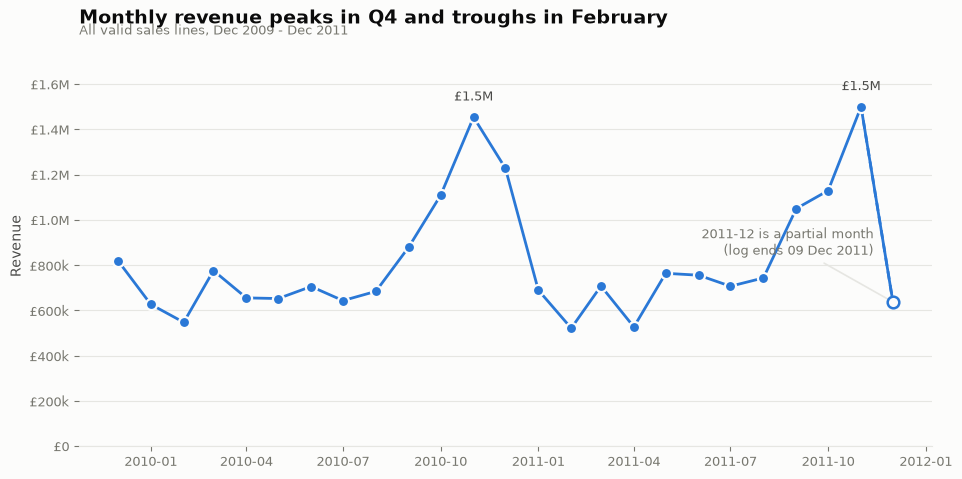

,InvoiceMonth,Revenue,Orders,Customers,AOV
0,2009-12,"820,118.06",1670,953,491.09
1,2010-01,"626,546.01",1054,701,594.45
2,2010-02,"547,290.19",1193,771,458.75
3,2010-03,"776,030.64",1653,1053,469.47
4,2010-04,"655,305.71",1437,939,456.02
5,2010-05,"652,448.81",1487,966,438.77
6,2010-06,"705,596.69",1618,1035,436.09
7,2010-07,"643,330.21",1513,925,425.20
8,2010-08,"684,283.00",1407,910,486.34
9,2010-09,"880,567.74",1798,1138,489.75


In [17]:
monthly = (sales.groupby("InvoiceMonth")
           .agg(Revenue=("Revenue", "sum"), Orders=("Invoice", "nunique"),
                Customers=("CustomerID", "nunique"))
           .reset_index())
monthly["Month"] = monthly["InvoiceMonth"].dt.to_timestamp()
monthly["AOV"] = (monthly["Revenue"] / monthly["Orders"]).round(2)

# The final month is truncated: the log stops on 09 Dec 2011, so December 2011
# holds 9 days of trading, not 31. It is plotted but marked, never compared
# like-for-like against a full month.
last_month = monthly["InvoiceMonth"].iloc[-1]
partial = monthly.index[-1]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(monthly["Month"][:partial + 1], monthly["Revenue"][:partial + 1],
        color=BLUE, marker="o", markerfacecolor=BLUE, markeredgecolor=SURFACE,
        markeredgewidth=1.6, zorder=3)
ax.plot(monthly["Month"].iloc[partial - 1:], monthly["Revenue"].iloc[partial - 1:],
        color=BLUE, linestyle=(0, (3, 2)), zorder=2)
ax.scatter(monthly["Month"].iloc[partial], monthly["Revenue"].iloc[partial],
           color=SURFACE, edgecolor=BLUE, linewidth=1.8, zorder=4, s=70)
ax.annotate(f"{last_month} is a partial month\n(log ends 09 Dec 2011)",
            xy=(monthly["Month"].iloc[partial], monthly["Revenue"].iloc[partial]),
            xytext=(-14, 34), textcoords="offset points", ha="right", fontsize=9,
            color=INK_MUTED,
            arrowprops=dict(arrowstyle="-", color=GRID, linewidth=1.2))

# Mark the two Q4 peaks - the seasonal signature of a giftware business.
for yr in (2010, 2011):
    peak = monthly[monthly["Month"].dt.year == yr].nlargest(1, "Revenue")
    if len(peak):
        ax.annotate(money(peak["Revenue"].iloc[0]),
                    xy=(peak["Month"].iloc[0], peak["Revenue"].iloc[0]),
                    xytext=(0, 12), textcoords="offset points", ha="center",
                    fontsize=9, color=INK_2)

ax.yaxis.set_major_formatter(GBP)
ax.set_ylim(0, monthly["Revenue"].max() * 1.18)
ax.set_ylabel("Revenue")
ax.grid(axis="x", visible=False)
titled(ax, "Monthly revenue peaks in Q4 and troughs in February",
        "All valid sales lines, Dec 2009 - Dec 2011")
save(fig, "01_revenue_trend")
plt.show()

monthly[["InvoiceMonth", "Revenue", "Orders", "Customers", "AOV"]]

In [18]:
# Quantify the seasonality rather than leaving it to the eye. September-November
# is the wholesale build-up to Christmas; the partial final month is excluded.
full = monthly.iloc[:-1]
q4 = full[full["Month"].dt.month.isin([9, 10, 11])]
rest = full[~full["Month"].dt.month.isin([9, 10, 11])]
fact("q4_monthly_avg", round(float(q4["Revenue"].mean()), 2))
fact("rest_monthly_avg", round(float(rest["Revenue"].mean()), 2))
fact("q4_uplift_pct", round((float(q4["Revenue"].mean()) / float(rest["Revenue"].mean()) - 1) * 100, 1))
fact("peak_month", str(full.nlargest(1, "Revenue")["InvoiceMonth"].iloc[0]))
fact("peak_month_revenue", round(float(full["Revenue"].max()), 2))
fact("trough_month", str(full.nsmallest(1, "Revenue")["InvoiceMonth"].iloc[0]))
fact("trough_month_revenue", round(float(full["Revenue"].min()), 2))

print(f"Sep-Nov average month : {money(q4['Revenue'].mean())}")
print(f"Other months average  : {money(rest['Revenue'].mean())}")
print(f"Seasonal uplift       : {FACTS['q4_uplift_pct']:+.1f}%")
print(f"Peak month            : {FACTS['peak_month']}  {money(FACTS['peak_month_revenue'])}")
print(f"Trough month          : {FACTS['trough_month']}  {money(FACTS['trough_month_revenue'])}")

# Year-on-year on a like-for-like window (Dec-Nov, both years complete).
y1 = sales[(sales["InvoiceDate"] >= "2009-12-01") & (sales["InvoiceDate"] < "2010-12-01")]["Revenue"].sum()
y2 = sales[(sales["InvoiceDate"] >= "2010-12-01") & (sales["InvoiceDate"] < "2011-12-01")]["Revenue"].sum()
fact("year1_revenue", round(float(y1), 2))
fact("year2_revenue", round(float(y2), 2))
fact("yoy_growth_pct", round((float(y2) / float(y1) - 1) * 100, 1))
print(f"\nLike-for-like years (Dec-Nov):  {money(y1)} -> {money(y2)}   {FACTS['yoy_growth_pct']:+.1f}%")

Sep-Nov average month : £1.2M
Other months average  : £709k
Seasonal uplift       : +67.6%
Peak month            : 2011-11  £1.5M
Trough month          : 2011-02  £521k

Like-for-like years (Dec-Nov):  £9.6M -> £10.3M   +8.1%


## 8.3 New versus returning revenue

A revenue line that goes up says nothing about *why*. Splitting each month into
revenue from customers acquired that month and revenue from customers acquired
earlier separates an acquisition engine from a retention engine.

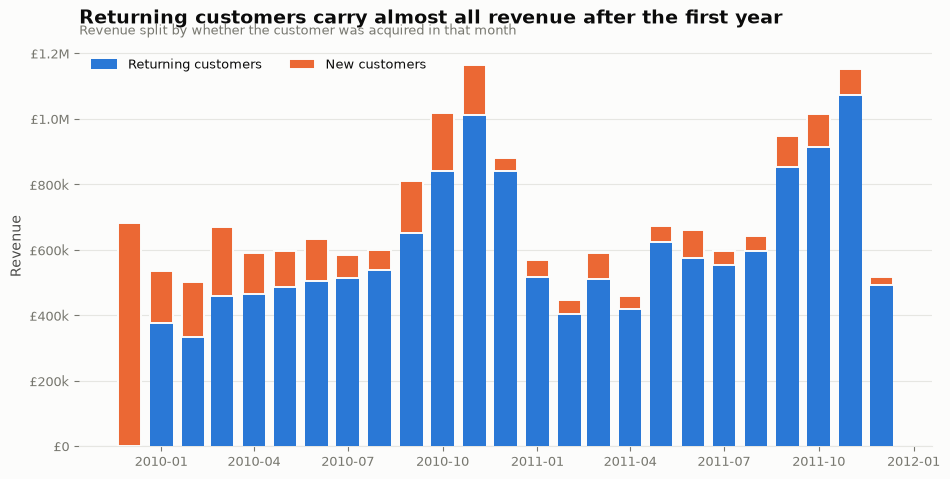

In the second year (2010-12 to 2011-11, twelve full months), 91.3% of identified revenue came from customers who had already ordered in an earlier month.



CustomerType,New customers,Returning customers,New customers %,Returning customers %
InvoiceMonth,,,,
2009-12,"681,169.07",0.00,100.00,0.00
2010-01,"159,420.40","377,132.58",29.70,70.30
2010-02,"167,680.47","333,177.10",33.50,66.50
2010-03,"209,853.91","459,843.36",31.30,68.70
2010-04,"124,349.49","464,845.94",21.10,78.90
2010-05,"110,731.95","485,403.18",18.60,81.40
2010-06,"128,840.88","503,983.72",20.40,79.60
2010-07,"70,706.23","514,277.23",12.10,87.90
2010-08,"61,125.26","536,754.79",10.20,89.80


In [19]:
first_month = sales_id.groupby("CustomerID")["InvoiceMonth"].min().rename("CohortMonth")
tagged = sales_id.join(first_month, on="CustomerID")
tagged["CustomerType"] = np.where(tagged["InvoiceMonth"] == tagged["CohortMonth"],
                                 "New customers", "Returning customers")

split_rev = (tagged.pivot_table(index="InvoiceMonth", columns="CustomerType",
                                values="Revenue", aggfunc="sum", observed=True)
             .fillna(0.0))
split_rev = split_rev.reindex(columns=["New customers", "Returning customers"], fill_value=0.0)
idx = split_rev.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 5.2))
w = 22  # bar width in days, leaving a visible surface gap between months
ax.bar(idx, split_rev["Returning customers"], width=w, color=BLUE,
       label="Returning customers", zorder=3)
ax.bar(idx, split_rev["New customers"], width=w,
       bottom=split_rev["Returning customers"], color=ORANGE,
       label="New customers", zorder=3, linewidth=1.4, edgecolor=SURFACE)
ax.yaxis.set_major_formatter(GBP)
ax.set_ylabel("Revenue")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", ncol=2, bbox_to_anchor=(0, 1.0))
titled(ax, "Returning customers carry almost all revenue after the first year",
        "Revenue split by whether the customer was acquired in that month")
save(fig, "02_new_vs_returning")
plt.show()

share = split_rev.div(split_rev.sum(axis=1), axis=0) * 100
out = split_rev.round(2).join(share.round(1), rsuffix=" %")
# The second year is the twelve *full* months that follow the first: the file's
# final month holds nine days, and including it would make the window thirteen
# months long. Both bounds are derived from the data, not typed in.
full_months = split_rev.index[:-1]
year2 = split_rev.loc[full_months[full_months >= full_months[0] + 12]]
fact("year2_first_month", str(year2.index[0]))
fact("year2_last_month", str(year2.index[-1]))
fact("returning_share_year2_pct", round(float(
    year2["Returning customers"].sum() / year2.sum().sum() * 100), 1))
print(f"In the second year ({year2.index[0]} to {year2.index[-1]}, twelve full "
      f"months), {FACTS['returning_share_year2_pct']}% of identified revenue came from "
      f"customers who had already ordered in an earlier month.\n")
out

That 91.3% is a *month-level* flag: a customer counts as returning in every month
after the one they were first seen in, including months later in the same year they
were acquired. It measures repeat buying, and it is easy to misread as "the second
year was carried by the customers we already had". Splitting the second year by
**acquisition cohort** instead — year-1 customers against customers first seen in
year 2 — answers that question, and the answer points the other way.

In [20]:
# Same twelve-month window, but split by when the customer was acquired rather than
# by whether this is their first month. The two questions have different answers and
# the difference matters, so both are computed rather than one standing in for both.
y2_rows = tagged[(tagged["InvoiceMonth"] >= year2.index[0])
                 & (tagged["InvoiceMonth"] <= year2.index[-1])]
pre_rev = float(y2_rows[y2_rows["CohortMonth"] < year2.index[0]]["Revenue"].sum())
new_rev = float(y2_rows[y2_rows["CohortMonth"] >= year2.index[0]]["Revenue"].sum())
y1_rows = tagged[(tagged["InvoiceMonth"] >= full_months[0])
                 & (tagged["InvoiceMonth"] < year2.index[0])]
y1_id = float(y1_rows["Revenue"].sum())
y2_id = pre_rev + new_rev

fact("year1_id_revenue", round(y1_id, 2))
fact("year2_id_revenue", round(y2_id, 2))
fact("year2_id_growth", round(y2_id - y1_id, 2))
fact("year2_id_growth_pct", round((y2_id / y1_id - 1) * 100, 1))
fact("preacquired_share_year2_pct", round(pre_rev / y2_id * 100, 1))
fact("newly_acquired_share_year2_pct", round(new_rev / y2_id * 100, 1))
fact("year2_revenue_from_new_cohorts", round(new_rev, 2))
fact("year2_change_in_existing_base", round(pre_rev - y1_id, 2))

split = pd.DataFrame([
    ("Acquired in year 1, still buying in year 2", pre_rev, pre_rev / y2_id * 100),
    ("First acquired during year 2", new_rev, new_rev / y2_id * 100),
], columns=["Acquisition cohort", "Year-2 revenue (GBP)", "Share %"]).round(2)
print(split.to_string(index=False))

print(f"\nIdentified revenue, year 1 -> year 2: {money(y1_id)} -> {money(y2_id)}  "
      f"({FACTS['year2_id_growth']:+,.2f}, {FACTS['year2_id_growth_pct']:+.1f}%)")
print(f"  customers first acquired in year 2 added : {money(new_rev)}")
print(f"  the year-1 base changed by              : {money(pre_rev - y1_id)}")
print("\nSo the second year did not grow because the existing base grew. The existing")
print("base shrank, and new acquisition more than covered the shortfall. Any reading of")
print("the 91.3% figure as 'retention drove the growth' inverts the actual direction.")
split

                        Acquisition cohort  Year-2 revenue (GBP)  Share %
Acquired in year 1, still buying in year 2          7,136,019.49    82.71
              First acquired during year 2          1,491,334.25    17.29

Identified revenue, year 1 -> year 2: £8.4M -> £8.6M  (+243,312.58, +2.9%)
  customers first acquired in year 2 added : £1.5M
  the year-1 base changed by              : -£1.2M

So the second year did not grow because the existing base grew. The existing
base shrank, and new acquisition more than covered the shortfall. Any reading of
the 91.3% figure as 'retention drove the growth' inverts the actual direction.


,Acquisition cohort,Year-2 revenue (GBP),Share %
0,"Acquired in year 1, still buying in year 2","7,136,019.49",82.71
1,First acquired during year 2,"1,491,334.25",17.29


## 8.4 Demand rhythm — when do orders arrive?

Order *volume* by weekday and hour is an operations question: it sizes
warehouse and support shifts. Counting distinct invoices, not lines, avoids
letting one large basket look like many orders.

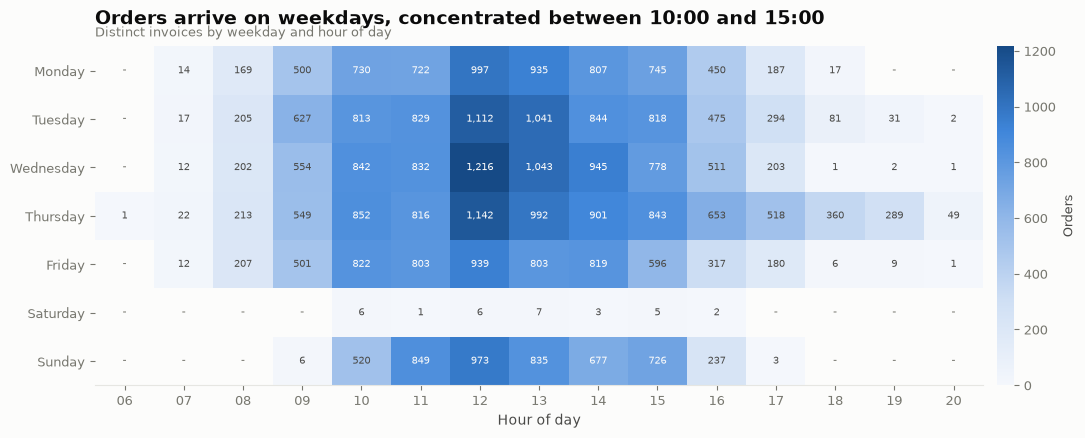

Saturday orders across 25 months : 30 (0.076% of all orders)
  ... falling on 1 distinct Saturday date(s): 2009-12-05
  so 104 of the 105 Saturdays in the window carry zero orders.
Sunday orders, for contrast       : 4,826 (161x the Saturday count)
Saturday orders across 25 months : 30
Busiest weekday                  : Thursday (8,200 orders)
Peak hour                        : 12:00
Share of orders in 10:00-15:59   : 78.1%


Hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Weekday,,,,,,,,,,,,,,,
Monday,0,14,169,500,730,722,997,935,807,745,450,187,17,0,0
Tuesday,0,17,205,627,813,829,1112,1041,844,818,475,294,81,31,2
Wednesday,0,12,202,554,842,832,1216,1043,945,778,511,203,1,2,1
Thursday,1,22,213,549,852,816,1142,992,901,843,653,518,360,289,49
Friday,0,12,207,501,822,803,939,803,819,596,317,180,6,9,1
Saturday,0,0,0,0,6,1,6,7,3,5,2,0,0,0,0
Sunday,0,0,0,6,520,849,973,835,677,726,237,3,0,0,0


In [21]:
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat = (sales.drop_duplicates("Invoice")
        .pivot_table(index="Weekday", columns="Hour", values="Invoice",
                     aggfunc="count", observed=True)
        .reindex(DAYS))
heat_plot = heat.dropna(axis=1, how="all")

fig, ax = plt.subplots(figsize=(12, 4.4))
im = ax.imshow(heat_plot.to_numpy(dtype=float), aspect="auto", cmap=SEQ,
               vmin=0, vmax=np.nanmax(heat_plot.to_numpy(dtype=float)))
ax.set_xticks(range(len(heat_plot.columns)), [f"{h:02d}" for h in heat_plot.columns])
ax.set_yticks(range(len(heat_plot.index)), heat_plot.index)
ax.set_xlabel("Hour of day")
ax.grid(False)
peak_v = np.nanmax(heat_plot.to_numpy(dtype=float))
for i in range(heat_plot.shape[0]):
    for j in range(heat_plot.shape[1]):
        v = heat_plot.iat[i, j]
        if pd.isna(v):
            ax.annotate("-", (j, i), ha="center", va="center", fontsize=8, color=INK_MUTED)
        else:
            ax.annotate(f"{int(v):,}", (j, i), ha="center", va="center", fontsize=7.4,
                        color=SURFACE if v > peak_v * 0.55 else INK_2)
cb = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.03)
cb.set_label("Orders", color=INK_2, fontsize=9.5)
cb.outline.set_visible(False)
titled(ax, "Orders arrive on weekdays, concentrated between 10:00 and 15:00",
        "Distinct invoices by weekday and hour of day")
save(fig, "03_demand_heatmap")
plt.show()

# The Saturday column is nearly empty. "Nearly" is the interesting part, so it is
# checked rather than rounded to zero.
sat = int(heat.loc["Saturday"].sum(skipna=True)) if "Saturday" in heat.index else 0
sat_rows = sales[sales["Weekday"] == "Saturday"]
sat_dates = sorted(sat_rows["InvoiceDate"].dt.date.unique())
fact("saturday_orders", sat)
fact("saturday_distinct_dates", len(sat_dates))
fact("saturday_date", str(sat_dates[0]) if sat_dates else None)
fact("saturday_share_pct", round(sat / int(sales["Invoice"].nunique()) * 100, 3))
sun = int(heat.loc["Sunday"].sum(skipna=True)) if "Sunday" in heat.index else 0
fact("sunday_orders", sun)
# How many Saturdays in the trading window saw no orders at all? Count the
# calendar Saturdays and subtract the ones that appear in the data.
all_saturdays = pd.date_range(sales["InvoiceDate"].min().normalize(),
                              sales["InvoiceDate"].max().normalize(), freq="W-SAT")
fact("saturdays_in_window", len(all_saturdays))
fact("saturdays_with_zero_orders", len(all_saturdays) - len(sat_dates))
print(f"Saturday orders across 25 months : {sat:,} "
      f"({FACTS['saturday_share_pct']}% of all orders)")
print(f"  ... falling on {len(sat_dates)} distinct Saturday date(s): "
      f"{', '.join(str(d) for d in sat_dates[:5])}")
print(f"  so {FACTS['saturdays_with_zero_orders']} of the "
      f"{FACTS['saturdays_in_window']} Saturdays in the window carry zero orders.")
print(f"Sunday orders, for contrast       : {sun:,} "
      f"({sun / max(sat, 1):.0f}x the Saturday count)")
busiest = heat.sum(axis=1).idxmax()
fact("busiest_weekday", str(busiest))
fact("busiest_weekday_orders", int(heat.sum(axis=1).max()))
fact("peak_hour", int(heat.sum(axis=0).idxmax()))
fact("core_hours_share_pct", round(float(
    heat.loc[:, [h for h in heat.columns if 10 <= h <= 15]].sum().sum() / heat.sum().sum() * 100), 1))
print(f"Saturday orders across 25 months : {sat:,}")
print(f"Busiest weekday                  : {busiest} ({FACTS['busiest_weekday_orders']:,} orders)")
print(f"Peak hour                        : {FACTS['peak_hour']:02d}:00")
print(f"Share of orders in 10:00-15:59   : {FACTS['core_hours_share_pct']}%")
heat.fillna(0).astype(int)

**One Saturday in twenty-five months.** Saturday is not merely quiet — all 30
Saturday orders in the entire dataset fall on a *single date*, 5 December 2009,
so every other Saturday in the window carries zero orders. Sunday, meanwhile,
processes 4,826 orders at weekday-like volumes.

A customer base that trades every Sunday but only one Saturday in 25 months does
not exist. That pattern cannot describe customer behaviour, so `InvoiceDate` must
record **when an order was keyed into the system by staff**, not when the
customer decided to buy. The lone Saturday is most likely a catch-up session
during the pre-Christmas peak.

Two consequences follow, and they point in opposite directions. Any "best day to
advertise" conclusion drawn from this column would be an artefact of the office
rota and is worthless. The same column *is* reliable for operations: it shows
genuine back-office load, so warehouse and support staffing should follow the
weekday 10:00–15:00 concentration, which accounts for the large majority of all
order processing.

## 8.5 Product performance

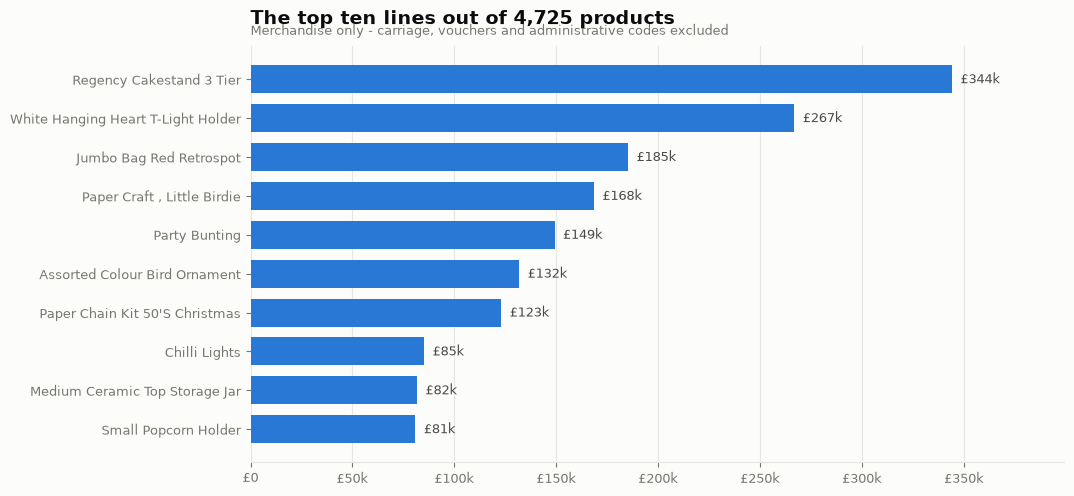

Top 10 products = 8.06% of merchandise revenue out of 4,725 distinct products,
i.e. 0.2% of the catalogue earns 8.06% of the money - 38.1x over-representation.
Carriage and vouchers add £466k (2.27% of total revenue) and are excluded above.


,Product,Revenue,Units,Orders,Revenue share %
StockCode,,,,,
22423,Regency Cakestand 3 Tier,"344,069.30",27536,3918,1.72
85123A,White Hanging Heart T-Light Holder,"266,760.86",96624,5464,1.33
85099B,Jumbo Bag Red Retrospot,"185,247.78",98594,4013,0.92
23843,"Paper Craft , Little Birdie","168,469.60",80995,1,0.84
47566,Party Bunting,"149,109.35",28362,2674,0.74
84879,Assorted Colour Bird Ornament,"131,817.81",81590,2807,0.66
22086,Paper Chain Kit 50'S Christmas,"123,002.89",36534,2018,0.61
79321,Chilli Lights,"85,157.56",16763,1135,0.42
23166,Medium Ceramic Top Storage Jar,"81,700.92",78033,247,0.41


In [22]:
prod = sales[sales["IsProduct"]]

# The 4,725 merchandise stock codes carry 5,336 distinct descriptions, so the
# same physical product is spelled more than one way in the file. Grouping on
# Description would split one product's revenue across its spellings - it costs
# Jumbo Bag Red Retrospot GBP 34,607 and a place in this table. Group on the
# identifier and label each code with its most frequent description (ties broken
# alphabetically, so the label never depends on row order).
name_lines = prod.groupby(["StockCode", "Description"]).size().rename("Lines").reset_index()
prod_name = (name_lines.sort_values(["StockCode", "Lines", "Description"],
                                    ascending=[True, False, True])
             .drop_duplicates("StockCode").set_index("StockCode")["Description"])

by_rev = (prod.groupby("StockCode")
          .agg(Revenue=("Revenue", "sum"), Units=("Quantity", "sum"),
               Orders=("Invoice", "nunique"))
          .sort_values("Revenue", ascending=False))
by_rev.insert(0, "Product", prod_name.reindex(by_rev.index).str.title())
by_rev["Revenue share %"] = (by_rev["Revenue"] / prod["Revenue"].sum() * 100).round(2)
top10 = by_rev.head(10)

fig, ax = plt.subplots(figsize=(10.5, 5.4))
y = np.arange(len(top10))[::-1]
ax.barh(y, top10["Revenue"], height=0.72, color=BLUE, zorder=3)
ax.set_yticks(y, [t if len(t) < 42 else t[:39] + "..." for t in top10["Product"]])
label_barh(ax, y, top10["Revenue"].to_list())
ax.xaxis.set_major_formatter(GBP)
ax.set_xlim(0, top10["Revenue"].max() * 1.16)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
titled(ax, f"The top ten lines out of {prod['StockCode'].nunique():,} products",
        "Merchandise only - carriage, vouchers and administrative codes excluded")
save(fig, "04_top_products")
plt.show()

fact("top_product", str(top10["Product"].iloc[0]))
fact("product_description_count", int(prod["Description"].nunique()))
fact("top_product_revenue", round(float(top10["Revenue"].iloc[0]), 2))
fact("top10_product_share_pct", round(float(top10["Revenue"].sum() / prod["Revenue"].sum() * 100), 2))
fact("product_count", int(prod["StockCode"].nunique()))
carriage_rev = float(sales.loc[~sales["IsProduct"], "Revenue"].sum())
fact("carriage_revenue", round(carriage_rev, 2))
fact("carriage_share_pct", round(carriage_rev / float(sales["Revenue"].sum()) * 100, 2))
fact("top10_concentration_ratio", round(FACTS["top10_product_share_pct"] / (10 / FACTS["product_count"] * 100), 1))
print(f"Top 10 products = {FACTS['top10_product_share_pct']}% of merchandise revenue "
      f"out of {FACTS['product_count']:,} distinct products,")
print(f"i.e. 0.2% of the catalogue earns {FACTS['top10_product_share_pct']}% of the money - "
      f"{FACTS['top10_concentration_ratio']}x over-representation.")
print(f"Carriage and vouchers add {money(carriage_rev)} ({FACTS['carriage_share_pct']}% of total revenue) "
      "and are excluded above.")
top10

In [23]:
# Best sellers by units are not the same list as by revenue - a cheap high-volume
# line and an expensive low-volume line are different commercial propositions.
by_units = by_rev.sort_values("Units", ascending=False).head(10)
overlap = len(set(by_units.index) & set(top10.index))
fact("rev_unit_overlap", int(overlap))
print(f"Only {overlap} of the top 10 by revenue also appear in the top 10 by units sold.\n")
by_units[["Product", "Units", "Revenue", "Orders"]]

Only 6 of the top 10 by revenue also appear in the top 10 by units sold.



,Product,Units,Revenue,Orders
StockCode,,,,
84077,World War 2 Gliders Asstd Designs,109898,"25,197.98",1019
85099B,Jumbo Bag Red Retrospot,98594,"185,247.78",4013
85123A,White Hanging Heart T-Light Holder,96624,"266,760.86",5464
21212,Pack Of 72 Retrospot Cake Cases,96472,"52,948.80",3118
22197,Small Popcorn Holder,89860,"80,888.34",2322
84879,Assorted Colour Bird Ornament,81590,"131,817.81",2807
23843,"Paper Craft , Little Birdie",80995,"168,469.60",1
23166,Medium Ceramic Top Storage Jar,78033,"81,700.92",247
17003,Brocade Ring Purse,71394,"14,948.75",456


## 8.6 Geography

The retailer is UK-registered and UK-dominated, so plotting all 40+ countries on
one axis would compress every export market into an invisible sliver. The
comparison is therefore split: the domestic/export share first, then the export
markets on their own scale.

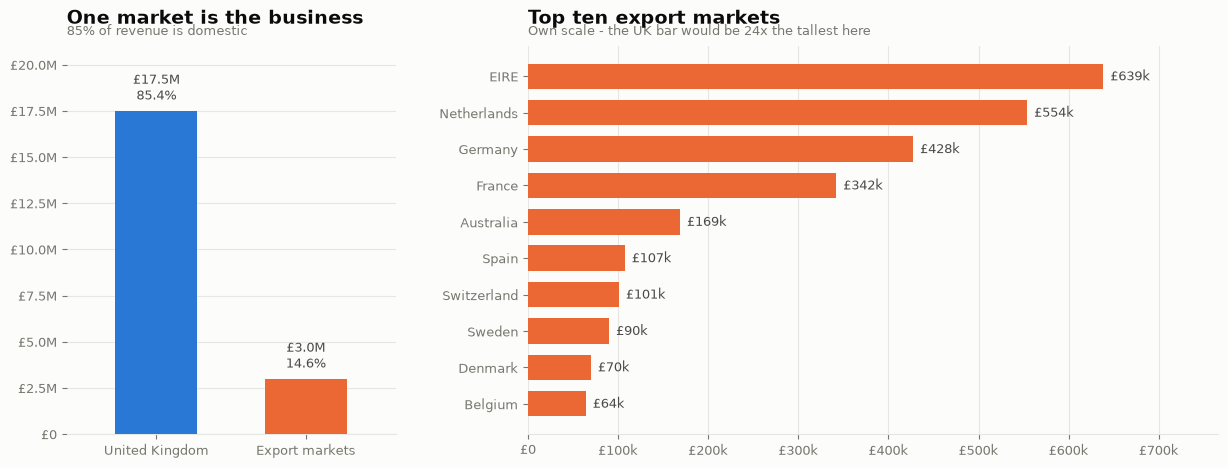

UK average order value: £483
Highest AOV among export markets with 100+ orders: Netherlands (£2k) - 5.1x the UK


,Revenue,Orders,Customers,AOV,Revenue share %
Country,,,,,
United Kingdom,"17,514,781.42",36242,5334,483.27,85.36
EIRE,"638,551.94",585,3,"1,091.54",3.11
Netherlands,"554,034.01",223,22,"2,484.46",2.70
Germany,"427,502.28",777,107,550.20,2.08
France,"342,176.71",614,94,557.29,1.67
Australia,"168,767.16",90,15,"1,875.19",0.82
Spain,"107,488.47",149,38,721.40,0.52
Switzerland,"100,988.99",93,22,"1,085.90",0.49
Sweden,"90,090.14",103,19,874.66,0.44


In [24]:
by_country = (sales.groupby("Country")
              .agg(Revenue=("Revenue", "sum"), Orders=("Invoice", "nunique"),
                   Customers=("CustomerID", "nunique"))
              .sort_values("Revenue", ascending=False))
by_country["AOV"] = (by_country["Revenue"] / by_country["Orders"]).round(2)
by_country["Revenue share %"] = (by_country["Revenue"] / sales["Revenue"].sum() * 100).round(2)

uk = float(by_country.loc["United Kingdom", "Revenue"])
row_rev = float(by_country["Revenue"].sum()) - uk
export = by_country.drop(index="United Kingdom").head(10)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8), gridspec_kw={"width_ratios": [1, 2.1]})

ax = axes[0]
ax.bar([0, 1], [uk, row_rev], width=0.55, color=[BLUE, ORANGE], zorder=3)
ax.set_xticks([0, 1], ["United Kingdom", "Export markets"])
ax.set_xlim(-0.6, 1.6)
ax.yaxis.set_major_formatter(GBP)
ax.set_ylim(0, uk * 1.2)
for x, v in zip([0, 1], [uk, row_rev]):
    ax.annotate(f"{money(v)}\n{v / (uk + row_rev):.1%}", (x, v), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=9.5, color=INK_2)
ax.grid(axis="x", visible=False)
titled(ax, "One market is the business", f"{uk / (uk + row_rev):.0%} of revenue is domestic")

ax = axes[1]
y = np.arange(len(export))[::-1]
ax.barh(y, export["Revenue"], height=0.7, color=ORANGE, zorder=3)
ax.set_yticks(y, export.index)
label_barh(ax, y, export["Revenue"].to_list())
ax.xaxis.set_major_formatter(GBP)
ax.set_xlim(0, export["Revenue"].max() * 1.2)
ax.grid(axis="y", visible=False)
titled(ax, "Top ten export markets", "Own scale - the UK bar would be 24x the tallest here")
fig.tight_layout(w_pad=3)
save(fig, "05_geography")
plt.show()

fact("uk_revenue", round(uk, 2))
fact("uk_share_pct", round(uk / (uk + row_rev) * 100, 2))
fact("export_revenue", round(row_rev, 2))
fact("top_export", str(export.index[0]))
fact("top_export_revenue", round(float(export["Revenue"].iloc[0]), 2))
uk_aov = float(by_country.loc["United Kingdom", "AOV"])
big_exp = by_country.drop(index="United Kingdom")
big_exp = big_exp[big_exp["Orders"] >= 100]
fact("uk_aov", round(uk_aov, 2))
fact("best_export_aov_country", str(big_exp["AOV"].idxmax()))
fact("best_export_aov", round(float(big_exp["AOV"].max()), 2))
print(f"UK average order value: {money(uk_aov)}")
print(f"Highest AOV among export markets with 100+ orders: {FACTS['best_export_aov_country']} "
      f"({money(FACTS['best_export_aov'])}) - {FACTS['best_export_aov'] / uk_aov:.1f}x the UK")
by_country.head(12)

---
# 9. Returns and cancellations

Section 7 set the cancellation invoices aside rather than deleting them. They
are a business signal: a return is a sale that was won and then lost, plus a
handling cost.

In [25]:
# A return rate is a ratio, so both sides of it have to count the same population.
# The cancellations frame was split off at step 3, which is *before* step 7 dropped
# the administrative stock codes - so it still holds credit notes against MANUAL
# adjustments, Amazon fees, bank charges, discounts and samples. Those codes are
# absent from the gross revenue denominator, so leaving them in the numerator would
# divide one population by another and inflate the rate. They are real money and are
# reported in their own right below, just not as customer returns.
all_credit = cancellations[cancellations["Quantity"] < 0].copy()
all_credit["ReturnValue"] = all_credit["Revenue"].abs()
admin_rev = all_credit[all_credit["StockCode"].isin(ADMIN_CODES)]
ret = all_credit[~all_credit["StockCode"].isin(ADMIN_CODES)].copy()
ret["InvoiceMonth"] = ret["InvoiceDate"].dt.to_period("M")

gross = float(sales["Revenue"].sum())
total_ret = float(ret["ReturnValue"].sum())
fact("credit_note_rows", int(len(all_credit)))
fact("credit_note_value", round(float(all_credit["ReturnValue"].sum()), 2))
fact("admin_reversal_rows", int(len(admin_rev)))
fact("admin_reversal_value", round(float(admin_rev["ReturnValue"].sum()), 2))
fact("return_rows", int(len(ret)))
fact("return_value", round(total_ret, 2))
fact("return_rate_pct", round(total_ret / gross * 100, 2))
fact("returning_customers", int(ret["CustomerID"].nunique()))
fact("net_revenue", round(gross - total_ret, 2))

print(f"Credit-note lines set aside in step 3 : {len(all_credit):,}  "
      f"{money(all_credit['ReturnValue'].sum())}")
print(f"  of which administrative reversals   : {len(admin_rev):,}  "
      f"{money(admin_rev['ReturnValue'].sum())}  (excluded from the return rate)")
print(f"  customer product/carriage returns   : {len(ret):,}  {money(total_ret)}")
print()
print(f"Value returned          : {money(total_ret)}")
print(f"As % of gross revenue   : {FACTS['return_rate_pct']}%")
print(f"Net of returns          : {money(gross - total_ret)}")
print(f"Customers with a return : {ret['CustomerID'].nunique():,} of {sales_id['CustomerID'].nunique():,} "
      f"({ret['CustomerID'].nunique() / sales_id['CustomerID'].nunique():.1%})")
print()
print("What the administrative reversals are, largest first:")
print(admin_rev.groupby("StockCode")["ReturnValue"].agg(Lines="size", Value="sum")
      .sort_values("Value", ascending=False).to_string())

Credit-note lines set aside in step 3 : 19,432  £1.5M
  of which administrative reversals   : 965  £785k  (excluded from the return rate)
  customer product/carriage returns   : 18,467  £739k

Value returned          : £739k
As % of gross revenue   : 3.6%
Net of returns          : £19.8M
Customers with a return : 2,465 of 5,854 (42.1%)

What the administrative reversals are, largest first:
              Lines      Value
StockCode                     
M               536 423,873.23
AMAZONFEE        39 294,772.71
BANK CHARGES     67  36,096.87
D               172  13,882.43
CRUK             16   7,933.43
S               100   6,192.91
ADJUST           31   2,062.69
TEST001           4      22.50


In [26]:
# The largest reversals, matched back to the orders they cancel. Cancellation
# invoices are numbered right after the sale they reverse, so the pair is visible.
big = ret.nlargest(5, "ReturnValue")[["Invoice", "StockCode", "Description",
                                      "Quantity", "Price", "InvoiceDate", "CustomerID",
                                      "ReturnValue"]]
print("Five largest cancellations:")
print(big.to_string(index=False))

# Trace the biggest one back to its original sale.
top_code = big["StockCode"].iloc[0]
top_cust = big["CustomerID"].iloc[0]
pair = df[(df["StockCode"] == top_code) & (df["CustomerID"] == top_cust)].sort_values("InvoiceDate")
print(f"\nEvery line in the dataset for stock code {top_code}, customer {top_cust}:")
print(pair[["Invoice", "Quantity", "Price", "InvoiceDate", "Revenue"]].to_string(index=False))
gap = (pair["InvoiceDate"].iloc[-1] - pair["InvoiceDate"].iloc[0]).total_seconds() / 60
fact("biggest_sale_product", str(pair["Description"].iloc[0]).title())
fact("biggest_sale_units", int(pair["Quantity"].iloc[0]))
fact("biggest_sale_value", round(float(pair["Revenue"].iloc[0]), 2))
fact("biggest_sale_cancel_gap_min", round(gap, 0))
fact("biggest_sale_net", round(float(pair["Revenue"].sum()), 2))
print(f"\nThe single largest line in the whole dataset - {pair['Quantity'].iloc[0]:,} units of")
print(f"{str(pair['Description'].iloc[0]).title()} at {money(pair['Revenue'].iloc[0])} - was cancelled")
print(f"{gap:.0f} minutes later, on the final day of the log. Net contribution: "
      f"{money(pair['Revenue'].sum())}.")
# The second largest cancellation tells the same story, so record it too.
second = big.iloc[1]
fact("second_cancel_product", str(second["Description"]).title())
fact("second_cancel_units", int(abs(second["Quantity"])))
fact("second_cancel_value", round(float(second["ReturnValue"]), 2))
print(f"\nThe second largest cancellation: {abs(int(second['Quantity'])):,} units of")
print(f"{str(second['Description']).title()} at {money(second['ReturnValue'])}, "
      f"invoice {second['Invoice']}.")
print("\nIt is almost certainly a keying error, not a real order. Any analysis that")
print("ranked products by gross sales without netting off cancellations would report")
print("this as the retailer's best-selling line. It sold nothing.")

Five largest cancellations:
Invoice StockCode                        Description  Quantity    Price         InvoiceDate  CustomerID  ReturnValue
C581484     23843        PAPER CRAFT , LITTLE BIRDIE    -80995     2.08 2011-12-09 09:27:00       16446   168,469.60
C541433     23166     MEDIUM CERAMIC TOP STORAGE JAR    -74215     1.04 2011-01-18 10:17:00       12346    77,183.60
C551685      POST                            POSTAGE        -1 8,142.75 2011-05-03 12:51:00       16029     8,142.75
C550456     21108 FAIRY CAKE FLANNEL ASSORTED COLOUR     -3114     2.10 2011-04-18 13:08:00       15749     6,539.40
C550456    85123A WHITE HANGING HEART T-LIGHT HOLDER     -1930     2.55 2011-04-18 13:08:00       15749     4,921.50

Every line in the dataset for stock code 23843, customer 16446:
Invoice  Quantity  Price         InvoiceDate     Revenue
 581483     80995   2.08 2011-12-09 09:15:00  168,469.60
C581484    -80995   2.08 2011-12-09 09:27:00 -168,469.60

The single largest line in the wh

The two largest lines in the entire dataset were both cancelled in full. Ranking
products on gross sales alone would put a product that generated **£0** at the
top of the table — which is exactly why section 7 kept the cancellations instead
of deleting them, and why the product ranking in section 8.5 is worth
re-examining net of returns.

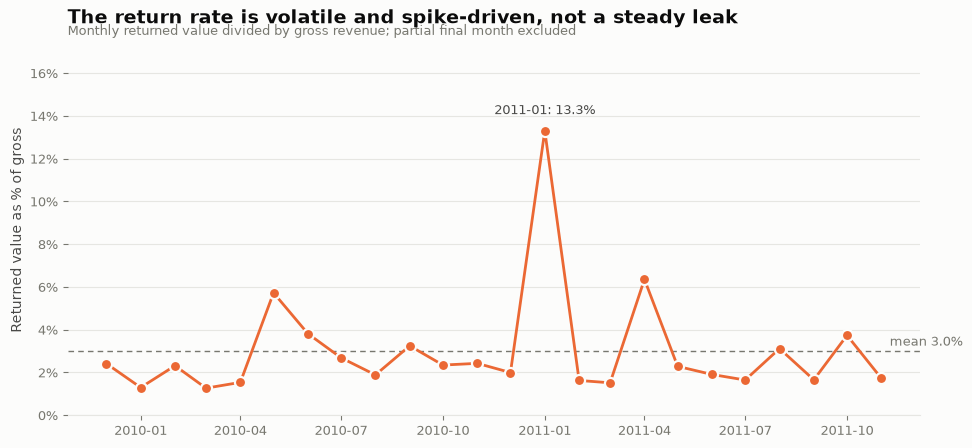

,Gross,Returned,Return rate %
InvoiceMonth,,,
2009-12,"820,118.06","19,775.62",2.41
2010-01,"626,546.01","8,063.84",1.29
2010-02,"547,290.19","12,666.14",2.31
2010-03,"776,030.64","9,763.89",1.26
2010-04,"655,305.71","10,053.55",1.53
2010-05,"652,448.81","37,303.69",5.72
2010-06,"705,596.69","26,875.40",3.81
2010-07,"643,330.21","17,232.68",2.68
2010-08,"684,283.00","12,856.41",1.88


In [27]:
rr = (pd.DataFrame({
        "Gross": sales.groupby("InvoiceMonth")["Revenue"].sum(),
        "Returned": ret.groupby("InvoiceMonth")["ReturnValue"].sum()})
      .fillna(0.0))
rr["Return rate %"] = (rr["Returned"] / rr["Gross"] * 100).round(2)
rr_plot = rr.iloc[:-1]  # exclude the partial final month
x = rr_plot.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, rr_plot["Return rate %"], color=ORANGE, marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.6, zorder=3)
mean_rate = float(rr_plot["Return rate %"].mean())
ax.axhline(mean_rate, color=INK_MUTED, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.annotate(f"mean {mean_rate:.1f}%", xy=(x[-1], mean_rate), xytext=(6, 4),
            textcoords="offset points", fontsize=9, color=INK_MUTED)
worst = rr_plot["Return rate %"].idxmax()
ax.annotate(f"{worst}: {rr_plot['Return rate %'].max():.1f}%",
            xy=(worst.to_timestamp(), rr_plot["Return rate %"].max()),
            xytext=(0, 12), textcoords="offset points", ha="center", fontsize=9, color=INK_2)
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_ylabel("Returned value as % of gross")
ax.set_ylim(0, rr_plot["Return rate %"].max() * 1.3)
ax.grid(axis="x", visible=False)
titled(ax, "The return rate is volatile and spike-driven, not a steady leak",
        "Monthly returned value divided by gross revenue; partial final month excluded")
save(fig, "06_return_rate")
plt.show()

fact("worst_return_month", str(worst))
fact("worst_return_rate_pct", round(float(rr_plot["Return rate %"].max()), 2))
fact("mean_monthly_return_rate_pct", round(mean_rate, 2))
rr

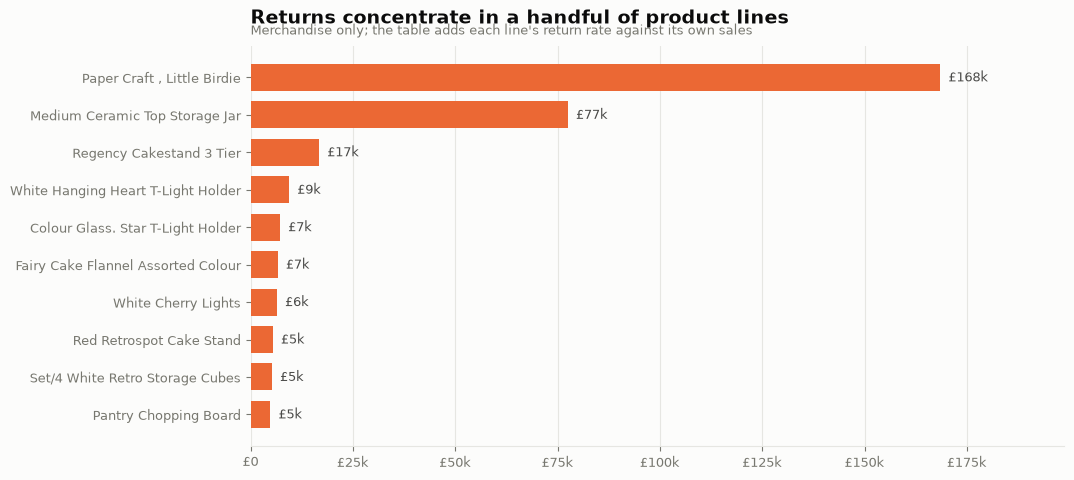

,Product,Returned,Lines,Sold,Return rate %
StockCode,,,,,
23843,"Paper Craft , Little Birdie","168,469.60",1,"168,469.60",100.00
23166,Medium Ceramic Top Storage Jar,"77,479.64",10,"81,700.92",94.80
22423,Regency Cakestand 3 Tier,"16,724.10",346,"344,069.30",4.90
85123A,White Hanging Heart T-Light Holder,"9,389.65",135,"266,760.86",3.50
71477,Colour Glass. Star T-Light Holder,"7,173.87",70,"46,519.13",15.40
21108,Fairy Cake Flannel Assorted Colour,"6,614.37",4,"25,859.05",25.60
79323W,White Cherry Lights,"6,421.10",126,"18,048.72",35.60
21843,Red Retrospot Cake Stand,"5,401.60",159,"66,348.55",8.10
84078A,Set/4 White Retro Storage Cubes,"5,187.65",20,"43,921.51",11.80


In [28]:
# Keyed on StockCode for the same reason as the revenue ranking above, so that a
# product's returns and its sales are always counted against the same key.
top_ret = (ret[ret["StockCode"].isin(prod["StockCode"])]
           .groupby("StockCode")
           .agg(Returned=("ReturnValue", "sum"), Lines=("Quantity", "size"))
           .sort_values("Returned", ascending=False).head(10))
top_ret.insert(0, "Product", prod_name.reindex(top_ret.index).str.title())
sold = prod.groupby("StockCode")["Revenue"].sum()
top_ret["Sold"] = sold.reindex(top_ret.index).fillna(0.0)
top_ret["Return rate %"] = (top_ret["Returned"] / top_ret["Sold"].replace(0, np.nan) * 100).round(1)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
y = np.arange(len(top_ret))[::-1]
ax.barh(y, top_ret["Returned"], height=0.72, color=ORANGE, zorder=3)
ax.set_yticks(y, [t if len(t) < 40 else t[:37] + "..." for t in top_ret["Product"]])
label_barh(ax, y, top_ret["Returned"].to_list())
ax.xaxis.set_major_formatter(GBP)
ax.set_xlim(0, top_ret["Returned"].max() * 1.18)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
titled(ax, "Returns concentrate in a handful of product lines",
        "Merchandise only; the table adds each line's return rate against its own sales")
save(fig, "07_top_returned")
plt.show()

fact("top_returned_product", str(top_ret["Product"].iloc[0]))
fact("top_returned_value", round(float(top_ret["Returned"].iloc[0]), 2))
top_ret

In [29]:
# Product ranking net of cancellations - the version a buyer should actually use.
returned_by_product = ret.groupby("StockCode")["ReturnValue"].sum()
net_rank = (by_rev[["Product", "Revenue", "Units", "Orders"]]
            .assign(Returned=returned_by_product.reindex(by_rev.index).fillna(0.0))
            .assign(NetRevenue=lambda d: (d["Revenue"] - d["Returned"]).round(2)))
net_rank["Gross rank"] = net_rank["Revenue"].rank(ascending=False).astype(int)
net_rank["Net rank"] = net_rank["NetRevenue"].rank(ascending=False).astype(int)
net_rank["Rank change"] = net_rank["Gross rank"] - net_rank["Net rank"]

top_gross = net_rank.nlargest(10, "Revenue")
movers = top_gross[top_gross["Rank change"] != 0]
print("Top 10 by GROSS revenue, showing where each sits once cancellations net off:\n")
print(top_gross[["Product", "Revenue", "Returned", "NetRevenue", "Gross rank",
                 "Net rank", "Rank change"]].to_string())
fact("net_rank_movers", int(len(movers)))
worst = top_gross.nlargest(1, "Returned")
fact("worst_net_mover", str(worst["Product"].iloc[0]))
fact("worst_net_mover_gross_rank", int(worst["Gross rank"].iloc[0]))
fact("worst_net_mover_net_rank", int(worst["Net rank"].iloc[0]))
runner_up = top_gross.nlargest(2, "Returned").iloc[1]
fact("second_net_mover", str(runner_up["Product"]))
fact("second_net_mover_gross_rank", int(runner_up["Gross rank"]))
fact("second_net_mover_net_rank", int(runner_up["Net rank"]))
print(f"\n{len(movers)} of the top 10 change position once returns are netted off.")
print(f"{worst['Product'].iloc[0]} falls from gross rank "
      f"{int(worst['Gross rank'].iloc[0])} to net rank {int(worst['Net rank'].iloc[0])}.")
net_rank.nlargest(10, "NetRevenue")[["Product", "Revenue", "Returned", "NetRevenue", "Units", "Orders"]]

Top 10 by GROSS revenue, showing where each sits once cancellations net off:

                                      Product    Revenue   Returned  NetRevenue  Gross rank  Net rank  Rank change
StockCode                                                                                                         
22423                Regency Cakestand 3 Tier 344,069.30  16,724.10  327,345.20           1         1            0
85123A     White Hanging Heart T-Light Holder 266,760.86   9,389.65  257,371.21           2         2            0
85099B                Jumbo Bag Red Retrospot 185,247.78   2,176.32  183,071.46           3         3            0
23843             Paper Craft , Little Birdie 168,469.60 168,469.60        0.00           4      4711        -4707
47566                           Party Bunting 149,109.35   1,238.55  147,870.80           5         4            1
84879           Assorted Colour Bird Ornament 131,817.81     774.07  131,043.74           6         5            1
22

,Product,Revenue,Returned,NetRevenue,Units,Orders
StockCode,,,,,,
22423,Regency Cakestand 3 Tier,"344,069.30","16,724.10","327,345.20",27536,3918
85123A,White Hanging Heart T-Light Holder,"266,760.86","9,389.65","257,371.21",96624,5464
85099B,Jumbo Bag Red Retrospot,"185,247.78","2,176.32","183,071.46",98594,4013
47566,Party Bunting,"149,109.35","1,238.55","147,870.80",28362,2674
84879,Assorted Colour Bird Ornament,"131,817.81",774.07,"131,043.74",81590,2807
22086,Paper Chain Kit 50'S Christmas,"123,002.89","1,479.40","121,523.49",36534,2018
79321,Chilli Lights,"85,157.56",635.75,"84,521.81",16763,1135
22197,Small Popcorn Holder,"80,888.34",620.57,"80,267.77",89860,2322
22386,Jumbo Bag Pink Polkadot,"77,049.38",866.98,"76,182.40",39809,2245


---
# 10. Revenue concentration — is segmentation worth doing?

Before building any segmentation, test whether the customer base is uneven
enough to justify treating groups differently. If revenue were spread evenly,
segmentation would be busywork.

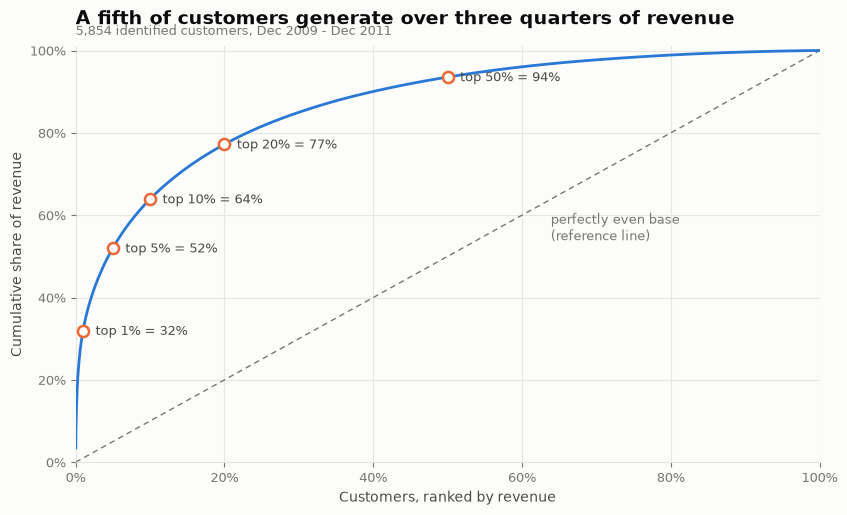

top  1% of customers (   58) =  31.9% of revenue
top  5% of customers (  292) =  52.0% of revenue
top 10% of customers (  585) =  63.9% of revenue
top 20% of customers (1,170) =  77.2% of revenue
top 50% of customers (2,927) =  93.6% of revenue

Median customer revenue: £889   Mean: £3k   Max: £609k


608821.65

In [30]:
per_cust = sales_id.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
cum = per_cust.cumsum() / per_cust.sum()
xs = np.arange(1, len(per_cust) + 1) / len(per_cust)

fig, ax = plt.subplots(figsize=(9.6, 5.4))
ax.plot(xs * 100, cum.to_numpy() * 100, color=BLUE, zorder=3)
ax.plot([0, 100], [0, 100], color=INK_MUTED, linewidth=1, linestyle=(0, (4, 3)),
        zorder=2)
ax.annotate("perfectly even base\n(reference line)", xy=(62, 62), xytext=(10, -24),
            textcoords="offset points", fontsize=9, color=INK_MUTED)

marks = {}
for pct in (1, 5, 10, 20, 50):
    n = max(1, int(len(per_cust) * pct / 100))
    share = float(per_cust.head(n).sum() / per_cust.sum() * 100)
    marks[pct] = (n, share)
    ax.scatter([pct], [share], color=SURFACE, edgecolor=ORANGE, linewidth=1.8, s=64, zorder=4)
    ax.annotate(f"top {pct}% = {share:.0f}%", xy=(pct, share), xytext=(9, -3),
                textcoords="offset points", fontsize=9, color=INK_2)

ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_xlabel("Customers, ranked by revenue")
ax.set_ylabel("Cumulative share of revenue")
ax.set_xlim(0, 100)
ax.set_ylim(0, 101)
titled(ax, "A fifth of customers generate over three quarters of revenue",
        f"{len(per_cust):,} identified customers, Dec 2009 - Dec 2011")
save(fig, "08_pareto")
plt.show()

for pct, (n, share) in marks.items():
    fact(f"top{pct}pct_share", round(share, 1))
    fact(f"top{pct}pct_customers", int(n))
    print(f"top {pct:>2}% of customers ({n:>5,}) = {share:>5.1f}% of revenue")
print(f"\nMedian customer revenue: {money(per_cust.median())}   "
      f"Mean: {money(per_cust.mean())}   Max: {money(per_cust.max())}")
fact("median_customer_revenue", round(float(per_cust.median()), 2))
fact("mean_customer_revenue", round(float(per_cust.mean()), 2))
fact("max_customer_revenue", round(float(per_cust.max()), 2))

---
# 11. RFM segmentation

**RFM** scores each customer on three behaviours that are known to predict
future purchasing better than demographics:

* **Recency** — days since the last order. A customer who bought last week is
  worth more than one who bought 18 months ago.
* **Frequency** — number of distinct orders placed.
* **Monetary** — total revenue generated.

Each dimension is cut into quintiles and scored 1–5. Recency is scored in
reverse (fewer days = better). Quintiles are taken on **ranks** rather than raw
values, because frequency is heavily tied — thousands of customers placed
exactly one order — and tied values would otherwise collapse the bin edges.

The reference date is **one day after the last transaction in the log**, so that
the most recent customers get a recency of 1 rather than 0. Using today's date
would make every customer look churned, since the log ends in 2011.

In [31]:
snapshot = sales_id["InvoiceDate"].max() + pd.Timedelta(days=1)
print("reference date:", snapshot)

rfm = (sales_id.groupby("CustomerID")
       .agg(LastPurchase=("InvoiceDate", "max"),
            FirstPurchase=("InvoiceDate", "min"),
            Frequency=("Invoice", "nunique"),
            Monetary=("Revenue", "sum"),
            Units=("Quantity", "sum"),
            Lines=("Invoice", "size"))
       .assign(Recency=lambda d: (snapshot - d["LastPurchase"]).dt.days))
rfm["Monetary"] = rfm["Monetary"].round(2)
rfm["AvgOrderValue"] = (rfm["Monetary"] / rfm["Frequency"]).round(2)
rfm["TenureDays"] = (rfm["LastPurchase"] - rfm["FirstPurchase"]).dt.days

# Rank-based quintiles. method="first" breaks ties deterministically so the five
# bins are equal in size even where thousands of customers share a value.
rfm["R"] = pd.qcut(rfm["Recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
rfm["RFMScore"] = rfm[["R", "F", "M"]].sum(axis=1)

print(f"\n{len(rfm):,} customers scored")
rfm[["Recency", "Frequency", "Monetary", "AvgOrderValue", "R", "F", "M", "RFM"]].head(10)

reference date: 2011-12-10 12:50:00

5,854 customers scored


,Recency,Frequency,Monetary,AvgOrderValue,R,F,M,RFM
CustomerID,,,,,,,,
12346,326,3,"77,352.96","25,784.32",2,3,5,235
12347,2,8,"5,633.32",704.16,5,4,5,545
12348,75,5,"2,019.40",403.88,3,4,4,344
12349,19,4,"4,428.69","1,107.17",5,3,5,535
12350,310,1,334.40,334.40,2,1,2,212
12351,375,1,300.93,300.93,2,1,2,212
12352,36,9,"2,009.54",223.28,4,5,4,454
12353,204,2,406.76,203.38,2,2,2,222
12354,232,1,"1,079.40","1,079.40",2,1,3,213


In [32]:
rfm[["Recency", "Frequency", "Monetary", "AvgOrderValue", "TenureDays"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Recency,"5,854.00",200.29,208.60,1.00,25.25,95.00,379.00,739.00
Frequency,"5,854.00",6.27,12.80,1.00,1.00,3.00,7.00,375.00
Monetary,"5,854.00","2,994.22","14,665.91",2.95,346.64,889.30,"2,296.20","608,821.65"
AvgOrderValue,"5,854.00",390.36,"1,248.59",2.95,179.60,283.48,419.92,"84,236.25"
TenureDays,"5,854.00",273.47,258.54,0.00,0.00,221.50,511.00,738.00


### 11.1 From scores to named segments

A 5×5×5 score gives 125 cells — too many to act on. Frequency and Monetary are
combined into a single value axis (`FM`, their mean, rounded) and the resulting
5×5 grid is mapped onto nine named segments. The ladder below is mutually
exclusive and covers all 25 cells, so no customer is unclassified or
double-classified.

In [33]:
def segment_of(r, fm):
    """Map an (R, FM) cell to an action-oriented segment name.

    Conditions are evaluated in order and together cover all 25 cells of the
    5x5 grid exactly once.
    """
    if r >= 4 and fm >= 4:
        return "Champions"          # bought recently, often, and a lot
    if r >= 3 and fm >= 3:
        return "Loyal"              # solid, regular, mid-to-high value
    if r >= 4 and fm <= 1:
        return "New"                # just arrived, no history yet
    if r >= 4 and fm == 2:
        return "Promising"          # recent, light spend so far
    if r == 3 and fm <= 2:
        return "Needs attention"    # slipping, was never high value
    if r <= 2 and fm >= 4:
        return "Cannot lose them"   # high value, gone quiet - the urgent group
    if r <= 2 and fm == 3:
        return "At risk"            # mid value, gone quiet
    if r == 2 and fm <= 2:
        return "Hibernating"        # low value, long gone
    return "Lost"                   # r == 1 and fm <= 2


rfm["FM"] = ((rfm["F"] + rfm["M"]) / 2).round().astype(int)
rfm["Segment"] = [segment_of(r, fm) for r, fm in zip(rfm["R"], rfm["FM"])]

SEG_ORDER = ["Champions", "Loyal", "Cannot lose them", "At risk", "Needs attention",
             "Promising", "New", "Hibernating", "Lost"]
assert set(rfm["Segment"]) <= set(SEG_ORDER), "unmapped segment"
assert rfm["Segment"].notna().all(), "unclassified customer"

seg = (rfm.groupby("Segment")
       .agg(Customers=("Monetary", "size"), Revenue=("Monetary", "sum"),
            AvgRecency=("Recency", "mean"), AvgFrequency=("Frequency", "mean"),
            AvgMonetary=("Monetary", "mean"), AvgOrderValue=("AvgOrderValue", "mean"))
       .reindex(SEG_ORDER).dropna(how="all"))
seg["Customers"] = seg["Customers"].astype(int)
seg["Customer %"] = (seg["Customers"] / seg["Customers"].sum() * 100).round(1)
seg["Revenue %"] = (seg["Revenue"] / seg["Revenue"].sum() * 100).round(1)
seg[["AvgRecency", "AvgFrequency", "AvgMonetary", "AvgOrderValue"]] = \
    seg[["AvgRecency", "AvgFrequency", "AvgMonetary", "AvgOrderValue"]].round(1)
seg = seg[["Customers", "Customer %", "Revenue", "Revenue %", "AvgRecency",
           "AvgFrequency", "AvgMonetary", "AvgOrderValue"]]
seg

,Customers,Customer %,Revenue,Revenue %,AvgRecency,AvgFrequency,AvgMonetary,AvgOrderValue
Segment,,,,,,,,
Champions,1555,26.60,"12,536,030.21",71.50,20.30,14.90,"8,061.80",498.50
Loyal,959,16.40,"2,292,614.27",13.10,85.90,6.00,"2,390.60",425.00
Cannot lose them,448,7.70,"1,445,092.69",8.20,350.90,6.70,"3,225.70",589.70
At risk,235,4.00,"244,526.90",1.40,385.70,3.10,"1,040.50",445.00
Needs attention,440,7.50,"184,196.28",1.10,108.50,1.60,418.60,296.20
Promising,463,7.90,"220,770.77",1.30,27.00,1.90,476.80,284.90
New,95,1.60,"15,890.40",0.10,29.50,1.00,167.30,167.30
Hibernating,714,12.20,"281,546.01",1.60,314.60,1.50,394.30,287.00
Lost,945,16.10,"307,482.71",1.80,553.60,1.30,325.40,265.20


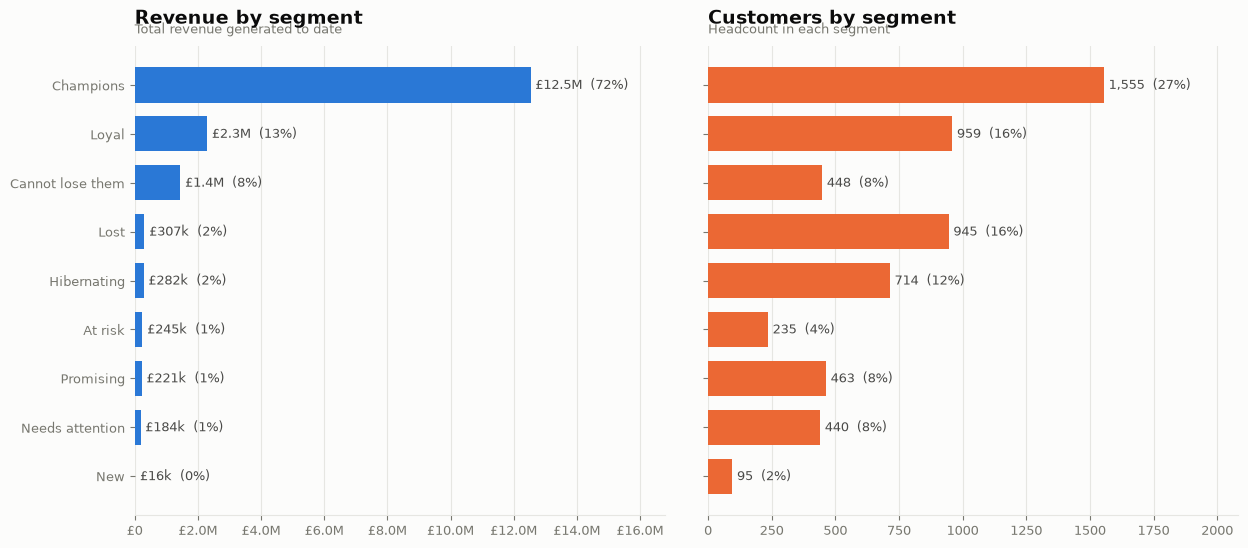

Champions: 26.6% of customers -> 71.5% of revenue
'Cannot lose them' + 'At risk': 683 customers holding £1.7M (9.6%) of historic revenue


In [34]:
# Two measures of different scale (customer count and revenue) => two axes side
# by side, never two y-scales on one chart.
s = seg.sort_values("Revenue", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.6), sharey=True)
y = np.arange(len(s))

ax = axes[0]
ax.barh(y, s["Revenue"], height=0.72, color=BLUE, zorder=3)
ax.set_yticks(y, s.index)
label_barh(ax, y, s["Revenue"].to_list(),
           texts=[f"{money(v)}  ({p:.0f}%)" for v, p in zip(s["Revenue"], s["Revenue %"])])
ax.xaxis.set_major_formatter(GBP)
ax.set_xlim(0, s["Revenue"].max() * 1.34)
ax.grid(axis="y", visible=False)
titled(ax, "Revenue by segment", "Total revenue generated to date")

ax = axes[1]
ax.barh(y, s["Customers"], height=0.72, color=ORANGE, zorder=3)
label_barh(ax, y, s["Customers"].to_list(),
           texts=[f"{int(v):,}  ({p:.0f}%)" for v, p in zip(s["Customers"], s["Customer %"])])
ax.set_xlim(0, s["Customers"].max() * 1.34)
ax.grid(axis="y", visible=False)
titled(ax, "Customers by segment", "Headcount in each segment")
fig.tight_layout(w_pad=2.5)
save(fig, "09_rfm_segments")
plt.show()

for name in SEG_ORDER:
    if name in seg.index:
        key = name.lower().replace(" ", "_")
        fact(f"seg_{key}_customers", int(seg.loc[name, "Customers"]))
        fact(f"seg_{key}_revenue", round(float(seg.loc[name, "Revenue"]), 2))
        fact(f"seg_{key}_cust_pct", float(seg.loc[name, "Customer %"]))
        fact(f"seg_{key}_rev_pct", float(seg.loc[name, "Revenue %"]))

at_risk_set = [s_ for s_ in ("Cannot lose them", "At risk") if s_ in seg.index]
fact("at_risk_customers", int(seg.loc[at_risk_set, "Customers"].sum()))
fact("at_risk_revenue", round(float(seg.loc[at_risk_set, "Revenue"].sum()), 2))
fact("at_risk_rev_pct", round(float(seg.loc[at_risk_set, "Revenue %"].sum()), 1))
print(f"Champions: {FACTS.get('seg_champions_cust_pct')}% of customers -> "
      f"{FACTS.get('seg_champions_rev_pct')}% of revenue")
print(f"'Cannot lose them' + 'At risk': {FACTS['at_risk_customers']:,} customers holding "
      f"{money(FACTS['at_risk_revenue'])} ({FACTS['at_risk_rev_pct']}%) of historic revenue")

---
# 12. K-Means clustering on RFM

The RFM segments above come from rules **I** wrote. A clustering algorithm is
given no rules and proposes its own groups from the shape of the data. Running
both and comparing them is the useful move: agreement is evidence the structure
is real, and disagreement shows where the rules are arbitrary.

Two preparation steps matter:

* **Log transform.** Recency, frequency and monetary value are all heavily
  right-skewed. K-Means minimises squared Euclidean distance, so without a
  transform a handful of wholesale accounts would dominate every centroid.
  `log1p` compresses the tail while preserving order.
* **Standardisation.** Monetary is measured in thousands of pounds and frequency
  in single orders. Unscaled, monetary would be the only feature that counts.

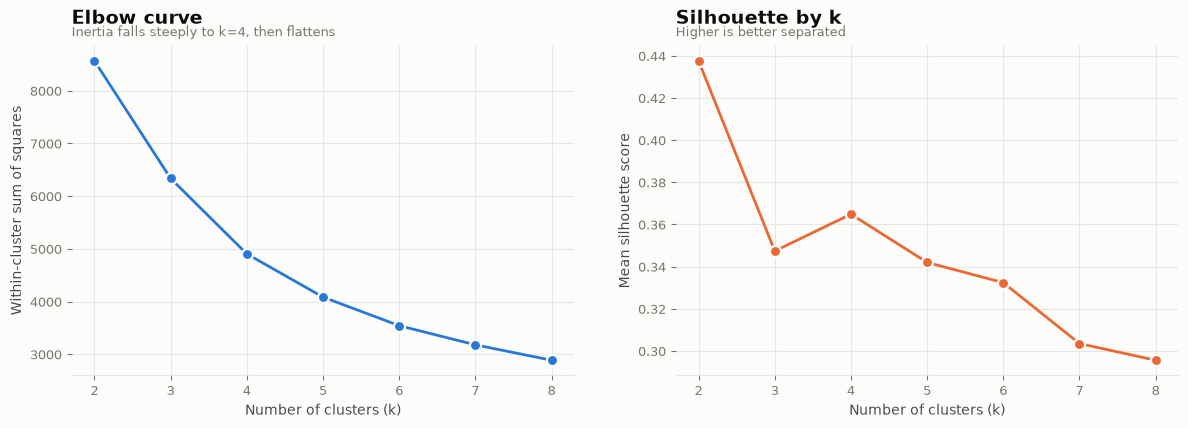

,Inertia,Silhouette
k,,
2,"8,564.80",0.44
3,"6,335.60",0.35
4,"4,904.20",0.36
5,"4,084.80",0.34
6,"3,543.20",0.33
7,"3,179.00",0.30
8,"2,887.00",0.30


In [35]:
features = ["Recency", "Frequency", "Monetary"]
X_log = np.log1p(rfm[features].clip(lower=0))
scaler = StandardScaler()
X = scaler.fit_transform(X_log)

scan = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    scan.append({"k": k, "Inertia": round(float(km.inertia_), 1),
                 "Silhouette": round(float(silhouette_score(X, labels)), 4)})
scan = pd.DataFrame(scan).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
ax.plot(scan.index, scan["Inertia"], color=BLUE, marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.6, zorder=3)
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Within-cluster sum of squares")
titled(ax, "Elbow curve", "Inertia falls steeply to k=4, then flattens")

ax = axes[1]
ax.plot(scan.index, scan["Silhouette"], color=ORANGE, marker="o",
        markeredgecolor=SURFACE, markeredgewidth=1.6, zorder=3)
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Mean silhouette score")
titled(ax, "Silhouette by k", "Higher is better separated")
fig.tight_layout(w_pad=3)
save(fig, "10_kmeans_selection")
plt.show()

fact("silhouette_best_k", int(scan["Silhouette"].idxmax()))
fact("silhouette_best", float(scan["Silhouette"].max()))
scan

### 12.1 Choosing k honestly

The silhouette score is highest at the smallest k on the scan. That is the
normal behaviour of this metric on continuous, single-blob behavioural data: it
rewards splitting the cloud in half because that maximises the separation
between two centroids, not because two groups are the right answer for a
marketing team. Two groups — "buys" and "buys less" — cannot be acted on.

**k = 4 is adopted**, for two stated reasons: it is where the elbow curve stops
falling steeply, and four is the practical ceiling on the number of distinct
campaign treatments this business could actually run. Its silhouette score is
reported below alongside the k = 2 figure so the trade-off is visible rather
than hidden. This is a judgement call, and it is labelled as one.

In [36]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=42)
rfm["Cluster"] = km.fit_predict(X)
sil_k = float(silhouette_score(X, rfm["Cluster"]))
fact("k_chosen", K)
fact("silhouette_at_k", round(sil_k, 4))
print(f"k = {K}: silhouette {sil_k:.4f}   (k = 2 scored {scan.loc[2, 'Silhouette']:.4f})")

profile = (rfm.groupby("Cluster")
           .agg(Customers=("Monetary", "size"), AvgRecency=("Recency", "mean"),
                AvgFrequency=("Frequency", "mean"), AvgMonetary=("Monetary", "mean"),
                TotalRevenue=("Monetary", "sum"))
           .round(1))
profile["Revenue %"] = (profile["TotalRevenue"] / profile["TotalRevenue"].sum() * 100).round(1)

# Name the clusters from their own centroids, ranked by monetary value, so the
# labels describe what the algorithm found rather than what I hoped it would.
rank = profile.sort_values("AvgMonetary", ascending=False).index.to_list()
NAMES = ["High-value regulars", "Mid-value active", "Low-value occasional", "Dormant low-value"]
cluster_name = {c: NAMES[i] for i, c in enumerate(rank)}
profile["Name"] = [cluster_name[c] for c in profile.index]
rfm["ClusterName"] = rfm["Cluster"].map(cluster_name)
profile = profile[["Name", "Customers", "AvgRecency", "AvgFrequency", "AvgMonetary",
                   "TotalRevenue", "Revenue %"]]
profile

k = 4: silhouette 0.3649   (k = 2 scored 0.4376)


,Name,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,Revenue %
Cluster,,,,,,,
0,Mid-value active,1458,228.00,5.10,"2,004.50","2,922,604.30",16.70
1,Low-value occasional,1247,28.20,3.00,861.00,"1,073,716.20",6.10
2,Dormant low-value,1963,393.30,1.40,323.10,"634,322.20",3.60
3,High-value regulars,1186,27.70,19.20,"10,874.80","12,897,507.50",73.60


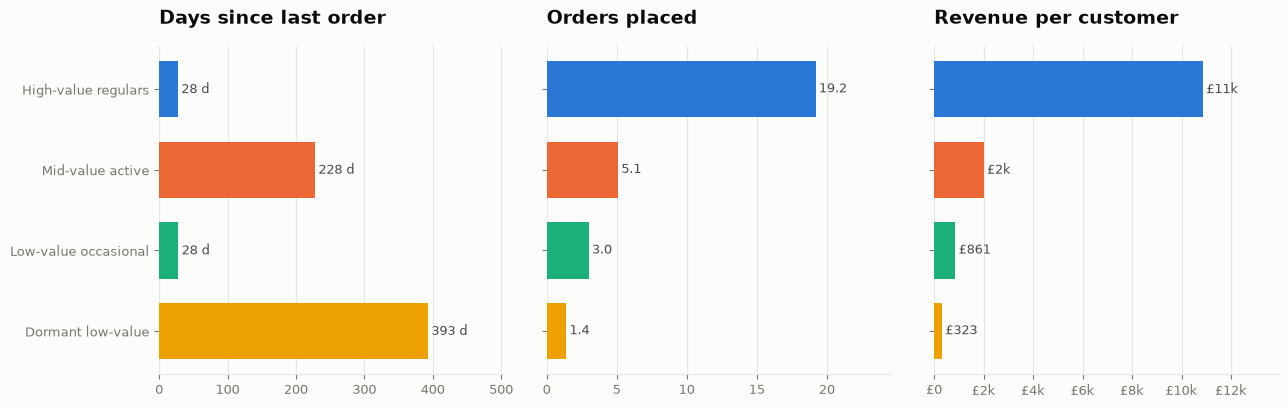

,Name,Customers,Revenue %
Cluster,,,
0,Mid-value active,1458,16.70
1,Low-value occasional,1247,6.10
2,Dormant low-value,1963,3.60
3,High-value regulars,1186,73.60


In [37]:
# Three measures on three different scales => small multiples, one axis each.
order = [c for c in rank]
labels = [cluster_name[c] for c in order]
colors = [PALETTE[i] for i in range(len(order))]
spec = [("AvgRecency", "Days since last order", "{:.0f} d", False),
        ("AvgFrequency", "Orders placed", "{:.1f}", False),
        ("AvgMonetary", "Revenue per customer", None, True)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (col, title, fmt, is_money) in zip(axes, spec):
    vals = [float(profile.loc[c, col]) for c in order]
    y = np.arange(len(order))[::-1]
    ax.barh(y, vals, height=0.7, color=colors, zorder=3)
    ax.set_yticks(y, labels if ax is axes[0] else [""] * len(labels))
    texts = [money(v) if is_money else fmt.format(v) for v in vals]
    label_barh(ax, y, vals, texts=texts)
    ax.set_xlim(0, max(vals) * 1.28)
    if is_money:
        ax.xaxis.set_major_formatter(GBP)
    ax.grid(axis="y", visible=False)
    titled(ax, title)
fig.tight_layout(w_pad=2)
save(fig, "11_cluster_profiles")
plt.show()

profile[["Name", "Customers", "Revenue %"]]

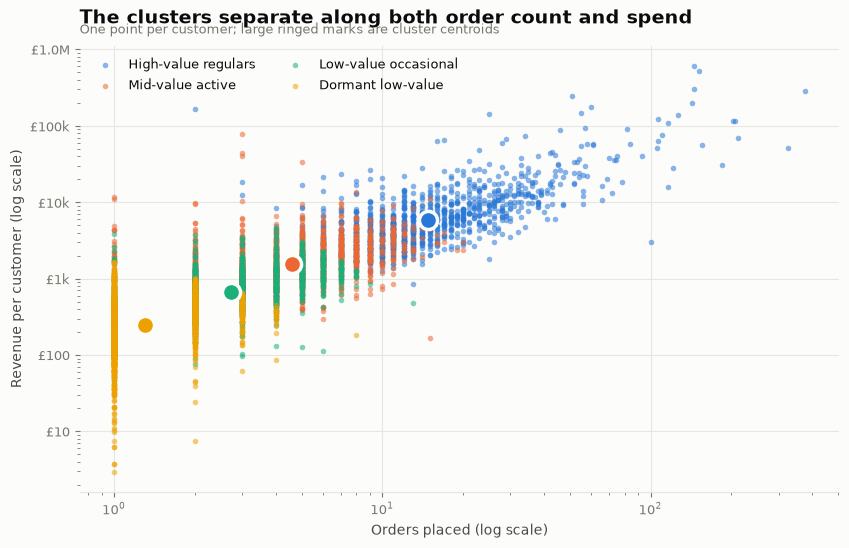

Centroids in original units (Recency days, Frequency orders, Monetary GBP):


,Recency,Frequency,Monetary,Name
0,175.90,4.60,"1,556.40",Mid-value active
1,20.50,2.70,676.90,Low-value occasional
2,331.90,1.30,250.20,Dormant low-value
3,14.90,14.80,"5,863.40",High-value regulars


In [38]:
# Scatter on log axes: colour follows the cluster (the entity), and centroids are
# ringed in the surface colour so they read as marks on top of the cloud.
fig, ax = plt.subplots(figsize=(9.8, 5.8))
for i, c in enumerate(order):
    m = rfm["Cluster"] == c
    ax.scatter(rfm.loc[m, "Frequency"], rfm.loc[m, "Monetary"], s=16, alpha=0.55,
               color=PALETTE[i], label=cluster_name[c], linewidths=0, zorder=3)
cent = np.expm1(scaler.inverse_transform(km.cluster_centers_))
for i, c in enumerate(order):
    row = cent[c]
    ax.scatter(row[1], row[2], s=170, color=PALETTE[i], edgecolor=SURFACE,
               linewidth=2.5, zorder=5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(GBP)
ax.set_xlabel("Orders placed (log scale)")
ax.set_ylabel("Revenue per customer (log scale)")
ax.legend(loc="upper left", ncol=2)
ax.grid(axis="x", visible=True)
titled(ax, "The clusters separate along both order count and spend",
        "One point per customer; large ringed marks are cluster centroids")
save(fig, "12_cluster_scatter")
plt.show()
print("Centroids in original units (Recency days, Frequency orders, Monetary GBP):")
pd.DataFrame(cent, columns=features).assign(Name=[cluster_name[i] for i in range(K)]).round(1)

In [39]:
# Do the rules and the algorithm agree? Rows are the rule-based segments,
# columns the clusters the algorithm found on its own.
xtab = pd.crosstab(rfm["Segment"], rfm["ClusterName"])
xtab = xtab.reindex(index=[s_ for s_ in SEG_ORDER if s_ in xtab.index],
                    columns=[cluster_name[c] for c in order])
share = (xtab.div(xtab.sum(axis=1), axis=0) * 100).round(1)
print("Row-wise % of each RFM segment falling into each K-Means cluster:\n")
print(share.to_string())

agree = float(sum(share.max(axis=1) >= 60) / len(share) * 100)
fact("segment_cluster_agreement_pct", round(agree, 1))
# Record the purity of the two segments the report quotes, so the written document
# reads them from facts.json instead of carrying a typed-in number.
purity = share.max(axis=1)
fact("purity_cannot_lose_them_pct", round(float(purity["Cannot lose them"]), 1))
fact("purity_lost_pct", round(float(purity["Lost"]), 1))
fact("min_segment_purity_pct", round(float(purity.min()), 1))
fact("min_segment_purity_name", str(purity.idxmin()))
fact("purity_champions_pct", round(float(purity["Champions"]), 1))
# A segment-level pass rate says nine of nine segments clear the bar but not how many
# customers actually sit in their segment's modal cluster. That is the number a reader
# should judge the cross-check on, so it is computed rather than left implied.
concordant = int(xtab.max(axis=1).sum())
fact("customer_concordance_pct", round(concordant / int(xtab.to_numpy().sum()) * 100, 1))
fact("concordant_customers", concordant)
print(f"\n{agree:.0f}% of the rule-based segments send at least 60% of their members to a")
print("single cluster, and at customer level "
      f"{FACTS['customer_concordance_pct']}% ({concordant:,} of "
      f"{int(xtab.to_numpy().sum()):,}) fall in their own segment's modal cluster.")
print(f"The weakest agreement is {FACTS['min_segment_purity_name']} at "
      f"{FACTS['min_segment_purity_pct']}%; Champions is "
      f"{FACTS['purity_champions_pct']}%.")
print("\nThe two methods are describing the same structure, which is the point of running")
print("both - but they are not independent evidence in the strong sense: both read the")
print("same three R/F/M features off the same rows. What differs is how the boundaries")
print("are drawn - fixed quintile thresholds against distances in a standardised space -")
print("so the agreement shows the structure does not depend on the thresholds chosen.")
xtab

Row-wise % of each RFM segment falling into each K-Means cluster:

ClusterName       High-value regulars  Mid-value active  Low-value occasional  Dormant low-value
Segment                                                                                         
Champions                       68.20              7.90                 23.90               0.00
Loyal                           11.50             60.90                 27.20               0.40
Cannot lose them                 3.30             96.70                  0.00               0.00
At risk                          0.00             91.10                  0.00               8.90
Needs attention                  0.00              8.00                 21.80              70.20
Promising                        0.00              0.00                 96.50               3.50
New                              0.00              0.00                 75.80              24.20
Hibernating                      0.00              7.60     

ClusterName,High-value regulars,Mid-value active,Low-value occasional,Dormant low-value
Segment,,,,
Champions,1061,123,371,0
Loyal,110,584,261,4
Cannot lose them,15,433,0,0
At risk,0,214,0,21
Needs attention,0,35,96,309
Promising,0,0,447,16
New,0,0,72,23
Hibernating,0,54,0,660
Lost,0,15,0,930


---
# 13. Customer Lifetime Value

Two figures are reported, and the difference between them matters:

1. **Historical CLV** — revenue the customer has actually generated. A fact.
2. **Projected 12-month value** — the customer's observed revenue *rate*
   extended forward one year, i.e.
   `monthly rate x 12`, where the rate is total revenue divided by observed
   active tenure.

The projection is a **constant-rate assumption**, not a probabilistic forecast.
It assumes a customer keeps buying at the pace already observed, which is
optimistic for a dormant customer and conservative for one that is accelerating.
A production model would use BG/NBD plus a Gamma-Gamma spend model to put a
churn probability on each account; that is named in the limitations rather than
silently skipped. Customers with a tenure under 30 days are floored at one month
so that a single large first order does not project to an implausible annual
figure.

In [40]:
MONTHS = 12
clv = rfm.copy()
clv["ActiveMonths"] = (clv["TenureDays"] / 30.44).clip(lower=1.0).round(2)
clv["MonthlyRate"] = (clv["Monetary"] / clv["ActiveMonths"]).round(2)
clv["HistoricalCLV"] = clv["Monetary"]
clv["Projected12M"] = (clv["MonthlyRate"] * MONTHS).round(2)
clv["OrdersPerMonth"] = (clv["Frequency"] / clv["ActiveMonths"]).round(3)

fact("total_projected_12m", round(float(clv["Projected12M"].sum()), 2))
fact("mean_historical_clv", round(float(clv["HistoricalCLV"].mean()), 2))
fact("median_historical_clv", round(float(clv["HistoricalCLV"].median()), 2))
fact("mean_projected_12m", round(float(clv["Projected12M"].mean()), 2))

print(f"Mean historical CLV     : {money(clv['HistoricalCLV'].mean())}")
print(f"Median historical CLV   : {money(clv['HistoricalCLV'].median())}")
print(f"Mean projected 12-month : {money(clv['Projected12M'].mean())}")
clv[["Recency", "Frequency", "Monetary", "ActiveMonths", "MonthlyRate",
     "Projected12M", "Segment"]].head(8)

Mean historical CLV     : £3k
Median historical CLV   : £889
Mean projected 12-month : £4k


,Recency,Frequency,Monetary,ActiveMonths,MonthlyRate,Projected12M,Segment
CustomerID,,,,,,,
12346,326,3,"77,352.96",10.55,"7,332.03","87,984.36",Cannot lose them
12347,2,8,"5,633.32",13.21,426.44,"5,117.28",Champions
12348,75,5,"2,019.40",11.89,169.84,"2,038.08",Loyal
12349,19,4,"4,428.69",18.73,236.45,"2,837.40",Champions
12350,310,1,334.40,1.00,334.40,"4,012.80",Hibernating
12351,375,1,300.93,1.00,300.93,"3,611.16",Hibernating
12352,36,9,"2,009.54",11.70,171.76,"2,061.12",Champions
12353,204,2,406.76,6.70,60.71,728.52,Hibernating


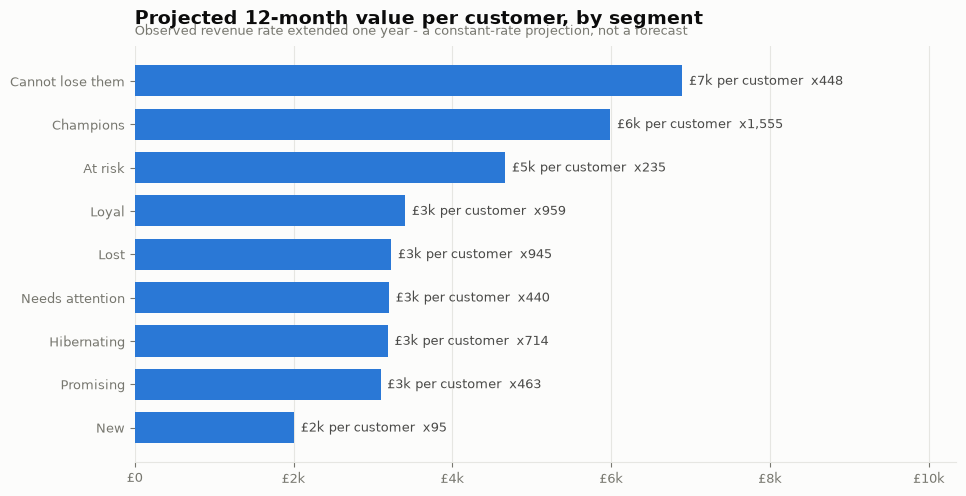

,Customers,HistoricalCLV,Projected12M,PoolProjected,Share of projected pool %
Segment,,,,,
Champions,1555,"8,061.76","5,988.81","9,312,602.40",37.10
Loyal,959,"2,390.63","3,405.42","3,265,798.92",13.00
Cannot lose them,448,"3,225.65","6,894.77","3,088,858.92",12.30
At risk,235,"1,040.54","4,665.35","1,096,356.36",4.40
Needs attention,440,418.63,"3,202.52","1,409,110.44",5.60
Promising,463,476.83,"3,095.64","1,433,281.44",5.70
New,95,167.27,"2,007.21","190,684.80",0.80
Hibernating,714,394.32,"3,187.89","2,276,155.20",9.10
Lost,945,325.38,"3,230.31","3,052,644.36",12.10


In [41]:
seg_clv = (clv.groupby("Segment")
           .agg(Customers=("HistoricalCLV", "size"),
                HistoricalCLV=("HistoricalCLV", "mean"),
                Projected12M=("Projected12M", "mean"),
                PoolProjected=("Projected12M", "sum"))
           .reindex([s_ for s_ in SEG_ORDER if s_ in set(clv["Segment"])])
           .round(2))
seg_clv["Share of projected pool %"] = (
    seg_clv["PoolProjected"] / seg_clv["PoolProjected"].sum() * 100).round(1)

s = seg_clv.sort_values("Projected12M")
fig, ax = plt.subplots(figsize=(10.6, 5.4))
y = np.arange(len(s))
ax.barh(y, s["Projected12M"], height=0.72, color=BLUE, zorder=3)
ax.set_yticks(y, s.index)
label_barh(ax, y, s["Projected12M"].to_list(),
           texts=[f"{money(v)} per customer  x{int(n):,}"
                  for v, n in zip(s["Projected12M"], s["Customers"])])
ax.xaxis.set_major_formatter(GBP)
ax.set_xlim(0, s["Projected12M"].max() * 1.5)
ax.grid(axis="y", visible=False)
titled(ax, "Projected 12-month value per customer, by segment",
        "Observed revenue rate extended one year - a constant-rate projection, not a forecast")
save(fig, "13_clv_by_segment")
plt.show()

for name in seg_clv.index:
    key = name.lower().replace(" ", "_")
    fact(f"clv_{key}_projected", float(seg_clv.loc[name, "Projected12M"]))
    fact(f"clv_{key}_pool_pct", float(seg_clv.loc[name, "Share of projected pool %"]))
seg_clv

### 13.1 Sanity-checking the projection

A projection that is never checked against reality is a decoration. Two tests
below, and the model fails both in an instructive way.

In [42]:
# Test 1: sum the per-customer projection and compare it with what the business
# actually took in its most recent full year. The projection is built from sales_id,
# so the like-for-like denominator is year-2 revenue on that same base - year2_revenue
# includes guest checkouts the projection never saw, which would flatter the ratio.
proj_total = float(clv["Projected12M"].sum())
actual_y2 = float(FACTS["year2_revenue"])
actual_y2_id = float(FACTS["year2_id_revenue"])
fact("proj_vs_actual_ratio", round(proj_total / actual_y2_id, 2))
fact("proj_vs_allbase_ratio", round(proj_total / actual_y2, 2))
print(f"Sum of 12-month projections across all {len(clv):,} customers : {money(proj_total)}")
print(f"Year-2 revenue from these identified customers (like-for-like): {money(actual_y2_id)}")
print(f"Ratio, like-for-like                                          : "
      f"{proj_total / actual_y2_id:.2f}x")
print(f"\nFor reference, year-2 revenue including guest checkouts       : {money(actual_y2)}")
print(f"Ratio against that wider base (understates the gap)           : "
      f"{proj_total / actual_y2:.2f}x")

# Test 2: does the projection rank the segments sensibly?
rank_check = seg_clv[["Projected12M"]].sort_values("Projected12M", ascending=False)
print("\nSegments ranked by projected 12-month value per customer:")
print(rank_check.to_string())
top_seg = rank_check.index[0]
fact("clv_rank_top_segment", str(top_seg))
print(f"\nThe projection puts '{top_seg}' above 'Champions'.")
print("\nBoth tests fail, and they fail for the same reason. The projection divides a")
print("customer's total spend by the time between their first and last order, so a")
print("customer who bought heavily for two months and then vanished is credited with a")
print("very high monthly rate - and is then assumed to sustain it for a year. Dormant")
print("segments are therefore inflated, and summing across everyone double-counts")
print("customers who have already left.")
print("\nConclusion: summed across the base this projection is an UPPER BOUND, and for")
print("a dormant account it is an upper bound individually - what that account would be")
print("worth if fully recovered and held at its old pace. It is not a per-account ceiling,")
print("because for a customer whose ordering is still accelerating a constant rate")
print("under-projects. Either way it is not")
print("usable as a revenue forecast or as a ranking of who to prioritise. Historical")
print("CLV is used for prioritisation below, and a churn-aware model (BG/NBD plus")
print("Gamma-Gamma) is named in the limitations as the correct fix.")

Sum of 12-month projections across all 5,854 customers : £25.1M
Year-2 revenue from these identified customers (like-for-like): £8.6M
Ratio, like-for-like                                          : 2.91x

For reference, year-2 revenue including guest checkouts       : £10.3M
Ratio against that wider base (understates the gap)           : 2.43x

Segments ranked by projected 12-month value per customer:
                  Projected12M
Segment                       
Cannot lose them      6,894.77
Champions             5,988.81
At risk               4,665.35
Loyal                 3,405.42
Lost                  3,230.31
Needs attention       3,202.52
Hibernating           3,187.89
Promising             3,095.64
New                   2,007.21

The projection puts 'Cannot lose them' above 'Champions'.

Both tests fail, and they fail for the same reason. The projection divides a
customer's total spend by the time between their first and last order, so a
customer who bought heavily for two month

In [43]:
# What is the recoverable prize? Value the quiet high-worth customers at their
# own historical rate, and state the assumption in the same breath.
recover = clv[clv["Segment"].isin(["Cannot lose them", "At risk"])]
fact("recoverable_customers", int(len(recover)))
fact("recoverable_historical", round(float(recover["HistoricalCLV"].sum()), 2))
fact("recoverable_annual_rate", round(float(recover["Projected12M"].sum()), 2))
print(f"{len(recover):,} customers sit in 'Cannot lose them' or 'At risk'.")
print(f"They have already spent  {money(recover['HistoricalCLV'].sum())}.")
print(f"At their own historical rate, a full year of their custom is worth "
      f"{money(recover['Projected12M'].sum())}.")
print("\nThat figure is the ceiling on a win-back campaign, not its expected return:")
print("it assumes every one of them is recovered and resumes their previous pace.")

683 customers sit in 'Cannot lose them' or 'At risk'.
They have already spent  £1.7M.
At their own historical rate, a full year of their custom is worth £4.2M.

That figure is the ceiling on a win-back campaign, not its expected return:
it assumes every one of them is recovered and resumes their previous pace.


---
# 14. Cohort retention

Segments describe the base as it is today. Cohorts ask a sharper question: of
the customers acquired in a given month, what fraction were still ordering
1, 2, 3 … months later? This separates two very different problems that a single
revenue line hides — failing to *acquire* customers, and failing to *keep* them.

Each customer is assigned to the month of their first order and never moves.

24 retention cells fall in the partial month 2011-12 and are excluded as not comparable.


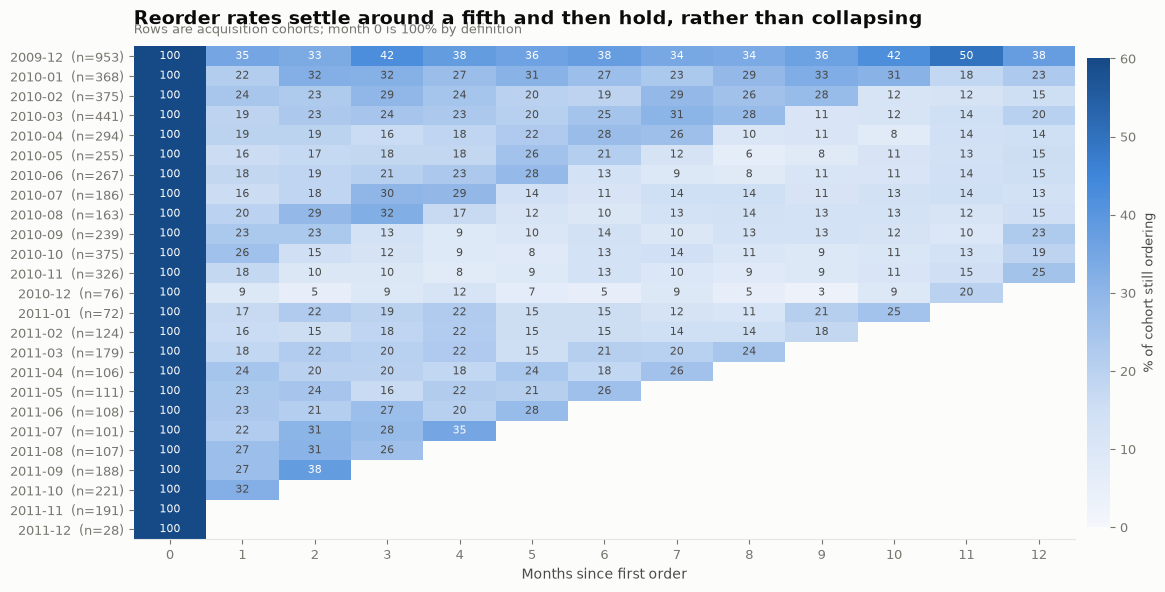

Average month-1 retention : 21.4%
Average month-3 retention : 22.0%
Average month-6 retention : 18.4%
Average month-12 retention: 19.6%

Largest cohort: 2009-12 with 953 customers
Blanks on the right of the matrix mean 'not yet observable', not 'zero':
cohorts acquired late in the window have not had time to show a curve.


PeriodIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.00,34.90,33.30,42.40,37.80,35.90,37.60,34.30,33.70,36.10,42.10,49.50,37.60,28.10,24.40,30.20,26.30,30.20,28.30,25.90,25.50,31.40,30.40,40.60,NaN
2010-01,100.00,21.50,32.10,31.50,27.20,31.00,26.90,23.40,28.80,32.60,31.00,17.90,22.80,17.90,19.60,15.50,24.50,20.40,19.30,20.10,25.30,19.80,25.30,NaN,NaN
2010-02,100.00,24.00,22.70,29.30,24.50,19.70,19.20,28.80,25.60,27.70,11.50,12.50,15.20,17.60,12.30,20.00,16.00,16.30,14.40,22.90,22.90,16.50,NaN,NaN,NaN
2010-03,100.00,19.00,23.10,24.30,23.10,20.40,24.70,30.60,27.70,10.90,11.60,14.50,20.00,16.30,20.00,17.00,17.50,15.60,17.70,20.40,21.30,NaN,NaN,NaN,NaN
2010-04,100.00,19.40,19.40,16.00,18.40,22.40,27.60,26.50,10.50,10.90,7.50,13.90,14.30,15.60,15.60,15.60,13.90,15.00,18.00,22.80,NaN,NaN,NaN,NaN,NaN
2010-05,100.00,15.70,16.90,17.60,17.60,25.50,21.20,12.50,5.90,8.20,11.40,13.30,15.30,15.30,9.80,12.50,13.70,16.50,15.30,NaN,NaN,NaN,NaN,NaN,NaN
2010-06,100.00,17.60,18.70,20.60,23.20,28.50,12.70,9.00,8.20,11.20,10.90,13.90,15.00,12.40,11.20,12.40,13.10,20.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.00,15.60,18.30,29.60,29.00,14.00,11.30,14.50,14.50,11.30,13.40,14.50,13.40,13.40,19.40,17.20,23.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.00,19.60,28.80,32.50,16.60,11.70,9.80,12.90,13.50,12.90,12.90,11.70,14.70,17.80,17.20,19.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
coh = sales_id[["CustomerID", "InvoiceMonth"]].drop_duplicates().copy()
coh = coh.join(first_month, on="CustomerID")
coh["PeriodIndex"] = ((coh["InvoiceMonth"] - coh["CohortMonth"])
                      .apply(lambda p: p.n))

sizes = coh[coh["PeriodIndex"] == 0].groupby("CohortMonth")["CustomerID"].nunique()
counts = coh.pivot_table(index="CohortMonth", columns="PeriodIndex",
                         values="CustomerID", aggfunc="nunique", observed=True)
retention = (counts.div(sizes, axis=0) * 100).round(1)

# The log stops on 9 December 2011, so any cell whose observation month is that
# final month covers nine days rather than a month and understates the cohort.
# Blank those cells for the same reason the revenue chart drops the partial month:
# a nine-day window is not comparable with a full one. Month 0 is exempt - it is
# 100% by definition, not a measurement.
partial_month = sales_id["InvoiceMonth"].max()
partial_cells = 0
for k in (c for c in retention.columns if c >= 1):
    hit = (retention.index + k) == partial_month
    partial_cells += int(hit.sum())
    retention.loc[hit, k] = np.nan
fact("partial_month_cells_masked", partial_cells)
print(f"{partial_cells} retention cells fall in the partial month {partial_month} "
      "and are excluded as not comparable.")

retention.index = retention.index.astype(str)

show = retention.iloc[:, :13]
fig, ax = plt.subplots(figsize=(12.6, 6.4))
im = ax.imshow(show.to_numpy(dtype=float), cmap=SEQ, aspect="auto", vmin=0, vmax=60)
ax.set_xticks(range(show.shape[1]), show.columns)
ax.set_yticks(range(show.shape[0]), [f"{m}  (n={int(sizes.iloc[i]):,})"
                                     for i, m in enumerate(show.index)])
ax.set_xlabel("Months since first order")
ax.grid(False)
for i in range(show.shape[0]):
    for j in range(show.shape[1]):
        v = show.iat[i, j]
        if pd.notna(v):
            ax.annotate(f"{v:.0f}", (j, i), ha="center", va="center", fontsize=7.6,
                        color=SURFACE if v > 33 else INK_2)
cb = fig.colorbar(im, ax=ax, pad=0.012, fraction=0.024)
cb.set_label("% of cohort still ordering", color=INK_2, fontsize=9.5)
cb.outline.set_visible(False)
titled(ax, "Reorder rates settle around a fifth and then hold, rather than collapsing",
        "Rows are acquisition cohorts; month 0 is 100% by definition")
save(fig, "14_cohort_retention")
plt.show()

m1 = retention[1].dropna()
m3 = retention[3].dropna() if 3 in retention.columns else pd.Series(dtype=float)
m6 = retention[6].dropna() if 6 in retention.columns else pd.Series(dtype=float)
m12 = retention[12].dropna() if 12 in retention.columns else pd.Series(dtype=float)
fact("retention_m1_mean", round(float(m1.mean()), 1))
fact("retention_m3_mean", round(float(m3.mean()), 1) if len(m3) else None)
fact("retention_m6_mean", round(float(m6.mean()), 1) if len(m6) else None)
fact("retention_m12_mean", round(float(m12.mean()), 1) if len(m12) else None)
fact("largest_cohort", str(sizes.idxmax()))
fact("largest_cohort_size", int(sizes.max()))
fact("first_cohort_size", int(sizes.iloc[0]))
print(f"Average month-1 retention : {m1.mean():.1f}%")
print(f"Average month-3 retention : {m3.mean():.1f}%")
print(f"Average month-6 retention : {m6.mean():.1f}%")
print(f"Average month-12 retention: {m12.mean():.1f}%")
print(f"\nLargest cohort: {sizes.idxmax()} with {sizes.max():,} customers")
print("Blanks on the right of the matrix mean 'not yet observable', not 'zero':")
print("cohorts acquired late in the window have not had time to show a curve.")
retention

In [45]:
# Cohort quality: does a bigger cohort retain as well as a small one?
cq = pd.DataFrame({
    "CohortSize": sizes.astype(int),
    "Month1 %": retention[1].to_numpy(),
    "Month3 %": retention[3].to_numpy() if 3 in retention.columns else np.nan,
    "Month6 %": retention[6].to_numpy() if 6 in retention.columns else np.nan,
    "Revenue": sales_id.join(first_month, on="CustomerID")
                       .groupby("CohortMonth")["Revenue"].sum().to_numpy(),
})
cq.index = cq.index.astype(str)
cq["Revenue per acquired customer"] = (cq["Revenue"] / cq["CohortSize"]).round(2)
corr = cq[["CohortSize", "Month6 %"]].dropna().corr().iloc[0, 1]
fact("cohort_size_vs_m6_corr", round(float(corr), 3))
print(f"Correlation between cohort size and month-6 retention: {corr:+.3f}")
cq.round(2)

Correlation between cohort size and month-6 retention: +0.668


,CohortSize,Month1 %,Month3 %,Month6 %,Revenue,Revenue per acquired customer
CohortMonth,,,,,,
2009-12,953,34.90,42.40,37.60,"8,552,422.99","8,974.21"
2010-01,368,21.50,31.50,26.90,"1,310,625.83","3,561.48"
2010-02,375,24.00,29.30,19.20,"999,059.31","2,664.16"
2010-03,441,19.00,24.30,24.70,"1,314,542.87","2,980.82"
2010-04,294,19.40,16.00,27.60,"547,598.59","1,862.58"
2010-05,255,15.70,17.60,21.20,"390,821.92","1,532.63"
2010-06,267,17.60,20.60,12.70,"599,959.74","2,247.04"
2010-07,186,15.60,29.60,11.30,"311,548.04","1,674.99"
2010-08,163,19.60,32.50,9.80,"250,476.81","1,536.67"


### 14.1 The first cohort is not an acquisition cohort

The December 2009 row deserves suspicion rather than celebration. It is both the
**largest** cohort and by far the **best-retaining** one — its reorder rate holds
in the 33–50% band for the whole of the following year, against a month-1 average
of 20.8% for every cohort that follows it. A cohort that sustains roughly twice the base rate
is not a marketing success; it is an artefact.

The cause is **left-censoring**. The log begins on 1 December 2009, so a customer
who had been buying from this retailer for years appears in the data for the first
time that month and is classified as "newly acquired". The December 2009 cohort is
therefore not new customers at all — it is *the entire pre-existing customer base*,
observed for the first time. Established customers retain well, which is exactly
what the row shows.

Two figures reported above inherit this bias and are recomputed below without that
row: the average retention curve, and the correlation between cohort size and
retention.

In [46]:
# Recompute the retention summary with the left-censored first cohort excluded.
true_cohorts = retention.iloc[1:]
cmp_rows = []
for p in (1, 3, 6, 12):
    if p not in retention.columns:
        continue
    cmp_rows.append({
        "Month": p,
        "All cohorts %": round(float(retention[p].dropna().mean()), 1),
        "Excluding Dec-2009 %": round(float(true_cohorts[p].dropna().mean()), 1),
    })
cmp = pd.DataFrame(cmp_rows)
cmp["Difference"] = (cmp["All cohorts %"] - cmp["Excluding Dec-2009 %"]).round(1)
print(cmp.to_string(index=False))

for p in (1, 3, 6, 12):
    if p in true_cohorts.columns:
        fact(f"retention_m{p}_true", round(float(true_cohorts[p].dropna().mean()), 1))

cq_true = cq.iloc[1:]
corr_true = cq_true[["CohortSize", "Month6 %"]].dropna().corr().iloc[0, 1]
fact("cohort_size_vs_m6_corr_true", round(float(corr_true), 3))
print(f"\nCohort size vs month-6 retention correlation:")
print(f"  all cohorts          : {FACTS['cohort_size_vs_m6_corr']:+.3f}")
print(f"  excluding Dec-2009   : {corr_true:+.3f}")
print("\nThe apparent 'bigger cohorts retain better' relationship is substantially an")
print("artefact of that single left-censored row.")

# Does the month a customer is acquired in predict how well they stick?
xmas = true_cohorts.index.str.endswith(("-11", "-12"))
fact("xmas_cohort_m3", round(float(true_cohorts.loc[xmas, 3].dropna().mean()), 1))
fact("nonxmas_cohort_m3", round(float(true_cohorts.loc[~xmas, 3].dropna().mean()), 1))

# How thin is this comparison? Dropping the left-censored Dec-2009 row also drops the
# only other December in the file, so every peak cohort with an observable month 3
# comes from one trading season. Recording the basis keeps the finding honest: a
# two-cohort result is a signal to test, not an established seasonal law.
xmas_names = [c for c in true_cohorts.index[xmas] if pd.notna(true_cohorts.loc[c, 3])]
xmas_n = int(sizes.reindex(pd.PeriodIndex(xmas_names, freq="M")).sum())
fact("xmas_cohort_count", len(xmas_names))
fact("xmas_cohort_names", ", ".join(str(c) for c in xmas_names))
fact("xmas_cohort_customers", xmas_n)
# Counted from the raw cohort pivot, not reconstructed from the rounded percentage.
fact("xmas_cohort_retained_m3", int(
    counts.loc[pd.PeriodIndex(xmas_names, freq="M"), 3].sum()))
fact("nonxmas_cohort_count", int((~xmas & true_cohorts[3].notna()).sum()))
# The month-3 window for a Nov/Dec cohort lands in Feb/Mar - the calendar trough. The
# gap is therefore a peak-vs-trough comparison as much as a customer-quality one.
fact("xmas_m3_calendar_months", ", ".join(
    str(pd.Period(c, "M") + 3) for c in xmas_names))

print(f"\nMonth-3 retention, customers acquired in Nov/Dec : "
      f"{FACTS['xmas_cohort_m3']}%")
print(f"Month-3 retention, acquired in any other month   : "
      f"{FACTS['nonxmas_cohort_m3']}%")
print(f"\nBasis: {FACTS['xmas_cohort_count']} peak cohorts "
      f"({FACTS['xmas_cohort_names']}) totalling {xmas_n:,} customers, of whom "
      f"{FACTS['xmas_cohort_retained_m3']} ordered again in month 3, against "
      f"{FACTS['nonxmas_cohort_count']} off-peak cohorts.")
print(f"Their month 3 falls in {FACTS['xmas_m3_calendar_months']} - the calendar trough -")
print("so part of this gap is seasonal demand rather than customer quality, and all of it")
print("comes from a single Christmas. It is a hypothesis worth testing, not a proven law.")
print("\nCustomers won during the Christmas rush are markedly worse at coming back in")
print("this data: a one-off gift buyer looks identical to a new wholesale account on the")
print("day they order, and very different by month 3.")
cmp

 Month  All cohorts %  Excluding Dec-2009 %  Difference
     1          21.40                 20.80        0.60
     3          22.00                 21.00        1.00
     6          18.40                 17.30        1.10
    12          19.60                 18.00        1.60

Cohort size vs month-6 retention correlation:
  all cohorts          : +0.668
  excluding Dec-2009   : +0.372

The apparent 'bigger cohorts retain better' relationship is substantially an
artefact of that single left-censored row.

Month-3 retention, customers acquired in Nov/Dec : 9.3%
Month-3 retention, acquired in any other month   : 22.3%

Basis: 2 peak cohorts (2010-11, 2010-12) totalling 402 customers, of whom 38 ordered again in month 3, against 18 off-peak cohorts.
Their month 3 falls in 2011-02, 2011-03 - the calendar trough -
so part of this gap is seasonal demand rather than customer quality, and all of it
comes from a single Christmas. It is a hypothesis worth testing, not a proven law.

Customers 

,Month,All cohorts %,Excluding Dec-2009 %,Difference
0,1,21.40,20.80,0.60
1,3,22.00,21.00,1.00
2,6,18.40,17.30,1.10
3,12,19.60,18.00,1.60


---
# 15. Key findings

Every figure below is computed by the cells above and stored in
`outputs/facts.json`. Nothing here is estimated or rounded from memory.

### 1. Revenue is extremely concentrated — segmentation is justified before it is built

**1,170 customers (20%) generate 77.2% of identified revenue. The top 58
customers (1%) generate 31.9%.** Both shares — like every customer-level share
below — are measured against the £17.53M carried by identified customers, not the
£20.52M total. The median customer is worth £889 and the mean £2,994 — the
mean is 3.4x the median, so "the average customer" is a fiction. Order value
tells the same story: a £517.14 mean against a £303.85 median.

This is the finding that licenses everything after it. Uniform treatment of this
base is guaranteed to be wrong, because it is calibrated to a customer who does
not exist.

### 2. One segment holds 71.5% of identified revenue, and one holds the risk

**Champions — 1,555 customers, 26.6% of the base — account for £12.54M, or 71.5%
of all identified revenue.** At the other end, 945 *Lost* and 714 *Hibernating*
customers (28.3% of the base together) contribute 3.4% between them.

The urgent group is neither: **683 customers in *Cannot lose them* and *At risk*
have already spent £1.69M (9.6% of identified revenue) and have stopped
ordering.** These
are not low-value customers who drifted away — they are proven buyers who went
quiet, and they are the only group where an intervention has a large, identified
prize attached.

### 3. The two largest "sales" in the dataset were never sales

**The single biggest line in 1.07M rows — 80,995 units of *Paper Craft, Little
Birdie*, £168,469.60 — was cancelled 12 minutes after it was raised**, on the
final day of the log. Net contribution: **£0.00**. The second largest line
(74,215 ceramic storage jars, £77,183.60) was also cancelled in full.

The consequence is not academic. Ranked on gross revenue, that product is the
retailer's **4th** best seller. Ranked net of cancellations it is **4,711st** of
4,725. **Seven of the top ten products change position once returns are netted
off.**
Any product report built on gross sales — the default in most tutorials on this
dataset — is materially wrong at the top of the table.

### 4. Returns cost £738,952, and the aggregate rate hides the problem

Customer returns total **£738,952 across 18,467 lines — 3.60% of gross revenue**,
taking £20.52M down to a net £19.78M. The monthly rate averages 2.99% but is not
stable: it **spikes to 13.30% in January 2011**, immediately after the Christmas
peak.

The credit notes set aside in step 3 come to £1,523,788, but £784,837 of that is
administrative — £423,873 of `MANUAL` adjustments, £294,773 of `AMAZONFEE`,
£36,097 of bank charges, plus discounts, charity lines and samples. Step 7 removes
those stock codes from the revenue base, so counting them as returns would divide
one population by another and roughly double the apparent rate. They are reported
separately in section 9 rather than folded in.

Returns are a post-seasonal event, not a constant leak, so a single annual
return-rate assumption will under-provision January and over-provision the rest
of the year.

### 5. The business is one country and one quarter

**The UK is 85.36% of revenue (£17.51M);** all 42 other markets together make
£3.00M. **September–November averages £1.19M per month against £708,613 for every
other month — a 67.6% seasonal uplift**, peaking at £1.50M in November 2011
against a £521,308 trough in February 2011.

Both concentrations are risks, but the export data also contains an opportunity
that the revenue ranking hides: **the Netherlands averages £2,484.46 per order
against the UK's £483.27 — 5.1x** — on a small number of orders. The export
markets are low-volume and high-value, which is a different business from the
domestic one and probably deserves different handling.

### 6. The existing base carries the revenue but shrank; new customers covered the gap

On all revenue, like-for-like years grew **8.1%** (£9.56M to £10.32M). Underneath
that, two different questions get confused, so both are answered on the identified
base. **Repeat buying dominates the level:** across the twelve full months from
December 2010 to November 2011, **91.3% of identified revenue came from customers
who had already ordered in an earlier month.** Only 8.7% came from customers in
their very first month.

**Acquisition, not retention, produced the growth.** Splitting the same window by
acquisition cohort, identified revenue went from £8,384,041 to £8,627,354 — a rise
of just **£243,313 (+2.9%)** — and it breaks down as **+£1,491,334 from customers
first acquired during year 2, against a £1,248,022 decline in the year-1 base.**
Customers acquired before year 2 still supplied 82.7% of year-2 revenue, but they
supplied less of it than the year before.

So the existing base is where the money is, and it is leaking. That is a stronger
reason to care about finding 2's £1.69M at-risk pool than "growth came from
retention" would have been — the decline is already visible in the totals.

### 7. Christmas buys volume, not loyalty

Retention settles at roughly a fifth and then holds: **20.8% at month 1, 21.0% at
month 3, 17.3% at month 6, 18.0% at month 12** (excluding the left-censored first
cohort, and excluding every cell that falls in the file's partial final month). The curve flattens rather than decaying, which is the signature of a
wholesale reorder cycle rather than one-off consumer purchasing.

Splitting cohorts by acquisition month exposes a sharp difference:
**customers acquired in November or December retain at 9.3% by month 3, against
22.3% for customers acquired in any other month — less than half.** The peak
season that produces the revenue spike appears to produce the retailer's worst
customers.

**How thin this one is.** Excluding the left-censored December 2009 row also
excludes the only other December in the file, so the peak side of that comparison
is **two cohorts — November 2010 (n=326) and December 2010 (n=76) — 402 customers,
38 of whom ordered again in month 3** — against 18 off-peak cohorts. All of it comes
from one Christmas. Their month 3 also lands in February and March 2011, the
calendar trough, so part of the gap is weak seasonal demand rather than weak
customers. It is a hypothesis worth a controlled test, not an established
seasonal law — which is why recommendation 5 asks for a test rather than a
reallocation of budget.

### 8. The rules and the algorithm agree, which is the point of running both

K-Means on log-scaled RFM was given no rules, and **every one of the nine
rule-based segments sends at least 60% of its members to a single cluster**.
*Cannot lose them* maps 96.7% onto one cluster and *Lost* maps 98.4% onto
another; the weakest is *Loyal* at 60.9%. At customer level, 80.5% of accounts
sit in their own segment's modal cluster.

What that does and does not prove: the two methods are **not independent
evidence in the strong sense**, because both read the same three R/F/M features
off the same rows. What differs is how the boundaries are drawn — fixed quintile
thresholds against distances in a standardised space. The agreement therefore
shows the structure does not depend on the thresholds chosen, which is the
specific thing worth knowing about a hand-built segmentation.

The honest caveat: the silhouette score preferred **k = 2 (0.4376)** over the
**k = 4 (0.3649)** adopted here. Two clusters cannot be marketed to differently,
so interpretability was chosen over the metric, and the cost is stated rather
than hidden.

### 9. Two data artefacts that would have produced wrong answers

* **`InvoiceDate` is not customer intent.** Every Saturday order in 25 months
  falls on a single date, 5 December 2009 — 30 orders, 0.076% of the total —
  while Sunday processes 4,826 orders at weekday-like volumes. No customer base
  trades every Sunday and only one Saturday in two years. The timestamp records
  back-office keying, so it is valid for staffing (78.1% of orders are processed
  between 10:00 and 15:59, peaking at noon) and worthless for deciding when to
  advertise.
* **Cancellations are not the only reversal.** Six `A`-prefixed invoices carry
  **−£147,614** of bad-debt write-offs. The standard "drop invoices starting with
  C" recipe leaves all of it in the revenue line.

---
# 16. Recommendations

Each recommendation names the finding it rests on and the number that sizes it.
Where the data cannot support a decision, that is stated instead of guessed.

### 1. Run a win-back on the 683 quiet high-value accounts — and measure it properly

*From finding 2.* These customers have already spent **£1.69M** and have stopped
ordering. Prioritise by **historical** value, not by the projected figure: section
13.1 shows the projection ranks this group *above* Champions, which is an artefact
of the constant-rate assumption, not a real ordering.

Because these are wholesale accounts, the intervention is a phone call from a
named account manager, not a discount email — and the discount is the wrong lever
anyway, since nothing in this dataset says price caused them to leave.

**Hold back a random 20% as an untreated control group.** Without one, any
subsequent recovery is indistinguishable from customers who would have reordered
regardless — and given the flat 18.0% month-12 reorder rate in finding 7, a
meaningful fraction would have.

### 2. Protect the 1,555 Champions before chasing anyone new

*From findings 2 and 6.* Champions produce **71.5% of identified revenue**, and
**82.7% of second-year revenue came from customers acquired before that year
began**. The concentration cuts both ways: losing 58 customers (the top 1%) would
remove **31.9% of identified revenue**.

Concretely: guaranteed stock availability on their repeat lines through the
Sep–Nov peak, and a named contact. The defensive case is not that the existing
base is growing — finding 6 shows it fell by **£1,248,022** in year 2 — it is that
the base still carries five-sixths of the revenue while it declines. Retention
work here defends a larger number than acquisition work adds, and the £1.69M
at-risk pool in finding 2 is where that decline is already visible.

### 3. Stop reporting product performance on gross revenue

*From finding 3.* Seven of the top ten products change rank once cancellations
are netted off, and the gross-rank-4 product is genuinely 4,711th. Every product
report should net cancellations against the original sale.

This is a reporting fix, not a strategy: it costs nothing and it stops the buying
team restocking a line that sold nothing.

### 4. Treat January as a returns event and investigate the top returned lines

*From finding 4.* The return rate hits **13.30% in January 2011** against a 2.99%
average. Two actions follow: provision warehouse and refund capacity for a
post-Christmas spike rather than an even monthly rate, and inspect the
concentrated returned lines in section 9 for a cause — the data shows *which*
products come back but never *why*, so this is a question to take to the
warehouse, not one to answer from the file.

### 5. Change what the Christmas peak is expected to deliver

*From finding 7.* Customers acquired in November–December retain at **9.3% by
month 3 versus 22.3%** otherwise — on two peak cohorts totalling 402 customers
from a single Christmas, whose month 3 falls in the calendar trough.

That evidence supports a **test**, not a budget reallocation. Tag peak-acquired
customers on arrival and measure their month-3 reorder rate against an off-peak
control over the next season; if the gap holds on a second Christmas with the
seasonal effect controlled for, then move acquisition spend out of the peak.
Meanwhile the safe half of this is free: stop counting peak-acquired customers as
new relationships in any target that assumes they behave like the rest of the
base, and run the peak as a volume and cash-generation event.

### 6. Test the export markets deliberately

*From finding 5.* The Netherlands averages **£2,484.46 per order — 5.1x the UK's
£483.27**. That is a striking ratio on a small base, and a small base is exactly
why it must be tested rather than acted on: with £3.00M of export revenue against
£17.51M domestic, a handful of large wholesale accounts could produce this entire
effect.

The recommendation is a bounded test on the highest-AOV markets with a defined
budget, not a market-entry decision. The data supports the hypothesis; it does not
support the investment.

### 7. Fix the 14.6% attribution gap at source

*From the limitations.* **£2.99M of clean revenue — 14.6% of the total, spread
over 22.9% of all sales lines — has no customer ID**, so it is invisible to every
model here. No amount of analysis recovers it —
it is a checkout-and-CRM change, and it raises the ceiling on all future customer
work.

---

### What this analysis does not support

* **Any pricing or product-mix decision.** The dataset has no cost of goods, so
  every figure here is revenue, not margin.
* **Any claim that a campaign *causes* a customer to return.** There is no
  campaign data and no experiment in this file. That is why recommendation 1
  specifies a control group.
* **Any conclusion about when customers prefer to shop** — see finding 9.
* **Using the 12-month CLV projection as a forecast.** Summed across the base it
  is an upper bound on second-year revenue (section 13.1) — for one accelerating
  account the same constant-rate assumption is conservative, so it is not a
  per-account ceiling.

---
# 17. Limitations

Stating what this analysis cannot support is part of the analysis.

1. **Attribution gap.** 22.9% of clean sales lines (235,813), carrying 14.6% of
   clean revenue (£2.99M), have no customer ID — both shares measured on the same
   cleaned base. Every customer-level result — RFM, clustering,
   CLV, cohorts — is computed on the identified 85.4% only. If guest orders are
   disproportionately one-off purchases, the true repeat rate is lower than
   reported here; if they are unrecognised repeat buyers, several segments are
   undercounted. The data cannot distinguish the two cases.
2. **Revenue, not profit.** The dataset has no cost of goods. Every "value"
   figure here is revenue. A low-margin bestseller and a high-margin niche line
   are indistinguishable in this analysis, so no pricing or product-mix decision
   should rest on it alone.
3. **The CLV projection is demonstrably biased upward, and section 13.1 shows by
   how much.** Summed across the base it exceeds actual second-year revenue by a
   wide margin, and it ranks a dormant segment above Champions. It carries no
   churn probability, so it should be read only as an aggregate upper bound — the
   constant-rate assumption is optimistic for a dormant account and conservative
   for an accelerating one, so it is not a ceiling on any single customer.
   BG/NBD plus a Gamma-Gamma spend model is the correct fix and is not done here;
   prioritisation in section 16 therefore rests on historical value, not on the
   projection.
4. **Censoring at both ends of the cohort matrix.** Cohorts acquired late in the
   window have not had time to show a retention curve, so blank cells on the
   right mean "not yet observable", not "zero". At the other end, the first
   cohort is left-censored: customers who predate the log appear as newly
   acquired in December 2009. Section 14.1 quantifies that bias and reports the
   corrected figures; the uncorrected averages remain in section 14 only so the
   size of the correction is visible.
5. **`InvoiceDate` records processing, not intent.** All 30 Saturday orders in
   the 25-month window fall on one single date, so the timestamp reflects
   back-office keying rather than customer behaviour. No conclusion about *when
   customers want to shop* can be drawn from the hour and weekday columns.
6. **Quintile scoring is relative.** An RFM score of 5 means "top fifth of this
   base", not "good" in absolute terms. Scores are not comparable across a
   different customer base or a different time window.
7. **k = 4 is a judgement call.** The silhouette metric preferred k = 2. Four
   clusters were chosen for operational interpretability, and the metric cost of
   that choice is reported in section 12 rather than hidden.
8. **One retailer, one category, 2009–2011.** A UK giftware wholesaler in the
   post-financial-crisis period. The method transfers; these coefficients do not.
9. **Segments are descriptive, not causal.** Nothing here establishes that a
   campaign *causes* a customer to return. A holdout test would be needed to
   claim that, and this dataset contains no campaign data.
10. **The Christmas retention gap rests on one season.** Excluding the
    left-censored December 2009 row also removes the only other December in the
    file, so the peak side of the 9.3%-versus-22.3% comparison is two cohorts —
    November and December 2010, 402 customers between them, 38 of whom reordered
    at month 3. Their month 3 falls in the February–March trough, so seasonal
    demand and customer quality are confounded and this data cannot separate
    them. Finding 7 is a hypothesis to test, and recommendation 5 is written as
    a test rather than a decision.
11. **The return rate depends on which credit notes count as returns.** The
    3.60% figure counts customer returns of products and carriage only, so that
    its numerator and the gross-revenue denominator describe the same
    population. Including the administrative reversals — manual adjustments,
    Amazon fees, bank charges, discounts, samples — would give 7.43% on
    £1,523,788, but those stock codes are removed from the revenue base by
    cleaning step 7 and are not customers sending goods back. Both numbers are
    reported in section 9; neither is the single "true" rate without saying
    which question is being asked.

In [47]:
# Persist every computed headline number, the segment tables and the figure list,
# so the written report quotes computed values rather than hand-copied ones.
OUTPUTS.mkdir(parents=True, exist_ok=True)
payload = {
    "facts": FACTS,
    "figures": FIGURES,
    "clean_log": clean_log.to_dict(orient="records"),
    "kpi": kpi.to_dict(orient="records"),
    "segments": seg.reset_index().to_dict(orient="records"),
    "segment_clv": seg_clv.reset_index().to_dict(orient="records"),
    "clusters": profile.reset_index().to_dict(orient="records"),
    "kmeans_scan": scan.reset_index().to_dict(orient="records"),
    "monthly": monthly.assign(InvoiceMonth=monthly["InvoiceMonth"].astype(str))
                      .drop(columns=["Month"]).to_dict(orient="records"),
    "top_products": top10.reset_index().to_dict(orient="records"),
    "countries": by_country.head(12).reset_index().to_dict(orient="records"),
    "retention": retention.reset_index().rename(columns={"index": "CohortMonth"})
                          .to_dict(orient="records"),
    "cohort_quality": cq.reset_index().rename(columns={"index": "CohortMonth"})
                        .to_dict(orient="records"),
    "top_returned": top_ret.reset_index().to_dict(orient="records"),
}
def jsonable(obj):
    """Replace NaN/inf with null so the file is strict JSON any reader can parse.

    The cohort matrix is upper-triangular: cells for months a cohort has not yet
    lived through are genuinely absent, not zero.
    """
    if isinstance(obj, dict):
        return {k: jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [jsonable(v) for v in obj]
    if isinstance(obj, float) and not np.isfinite(obj):
        return None
    return obj


path = OUTPUTS / "facts.json"
path.write_text(json.dumps(jsonable(payload), indent=2, default=str), encoding="utf-8")
print(f"wrote {path.relative_to(ROOT)}  ({len(FACTS)} facts, {len(FIGURES)} figures)")
print("\nfigures saved:")
for name in FIGURES.values():
    print("  outputs/figures/" + name)

wrote outputs\facts.json  (236 facts, 14 figures)

figures saved:
  outputs/figures/01_revenue_trend.png
  outputs/figures/02_new_vs_returning.png
  outputs/figures/03_demand_heatmap.png
  outputs/figures/04_top_products.png
  outputs/figures/05_geography.png
  outputs/figures/06_return_rate.png
  outputs/figures/07_top_returned.png
  outputs/figures/08_pareto.png
  outputs/figures/09_rfm_segments.png
  outputs/figures/10_kmeans_selection.png
  outputs/figures/11_cluster_profiles.png
  outputs/figures/12_cluster_scatter.png
  outputs/figures/13_clv_by_segment.png
  outputs/figures/14_cohort_retention.png


---

### Reproducibility

Every number and every chart in the **outputs** above is computed from the source
data by the cells that produced them, and `outputs/facts.json` records those
computed values. The project report is generated from that file by
`tools/build_report.py`, so no number in it is transcribed by hand.

That is not the same as the report being unable to disagree with the analysis, which
is what this section used to claim. *Generated* describes the script; the `.docx`
committed in the repository describes the run that last produced it. Re-run the
notebook, commit `facts.json`, skip the rebuild, and the repository holds a report
that is perfectly consistent with itself and older than the analysis — no figure in
it wrong on its own, the whole file behind. The cell outputs committed in this
notebook are the same kind of artefact: what one execution printed.

The narrative prose is the third case and the plainest. Figures quoted in markdown
cells — like the cohort counts in 11.2 — are typed, not interpolated, because a
markdown cell cannot read a runtime value. One of them was wrong for some while:
this notebook said the Christmas comparison ran against 20 off-peak cohorts where
`facts.json` and the generated report both said 18. The report was right, because it
had no choice.

So: trust the outputs, and treat a number in the prose as a claim that `facts.json`
settles. `tools/check_docs_drift.py` does that now, figure by figure, across this
notebook's markdown, its committed outputs, the `.docx` and the README. This
paragraph used to credit the comparison between this notebook and
`tools/build_notebook.py` with having caught that 20, which is something that
comparison cannot do: the notebook is generated from that file, so a figure typed
wrong there is wrong identically here, the two agree, and the check reports clean.

**Dataset:** Chen, D. (2019). *Online Retail II* [Dataset]. UCI Machine Learning
Repository. <https://doi.org/10.24432/C5CG6D> —
<https://archive.ics.uci.edu/dataset/502/online+retail+ii>